# SAND Challenge - Task 2: ALS Progression Prediction
## 5-Fold Cross-Validation Approach

## Objective
Predict the ALSFRS-R score at the **last follow-up visit** based on:
- Audio features from 8 recordings (5 vowels + 3 syllables)
- Temporal information (months between assessments)
- Initial ALSFRS-R score

## Task Details
- **Classes**: 4 (ALS with dysarthria levels 1-4, no healthy subjects)
- **Metric**: Averaged F1-Score (macro)
- **Baseline**: PART Algorithm (F1 = 0.583)
- **Current Best**: ISDS Team (F1 = 0.5794)

## Evaluation Strategy
**Following professor's guidelines:**
- Combine train + validation sets (132 samples total)
- 5-fold stratified cross-validation
- Report: Mean F1 ± Std across 5 folds

## Approach
1. **Multi-Model Feature Extraction**: Wav2Vec2 + HuBERT
2. **Feature Fusion**: Concatenate audio + temporal features
3. **Ensemble Learning**: Multiple classifiers with 5-fold CV

## 1. Setup and Imports

### 1.1 Install Required Packages (if needed)

In [1]:
# Uncomment if packages need to be installed
# !pip install transformers soundfile torch scikit-learn xgboost pandas numpy matplotlib seaborn tqdm imbalanced-learn

### 1.2 Import Libraries

In [2]:
import numpy as np
import pandas as pd
import torch
from transformers import Wav2Vec2Model, Wav2Vec2Processor, HubertModel, Wav2Vec2FeatureExtractor
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from pathlib import Path
import warnings
from tqdm import tqdm
from scipy.signal import resample
from typing import List, Optional, Tuple, Dict
import json
from datetime import datetime
import pickle

# Sklearn imports
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    make_scorer, accuracy_score, balanced_accuracy_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)

print("✓ All libraries imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS (Apple GPU) available: {torch.backends.mps.is_available() if hasattr(torch.backends, 'mps') else False}")

/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All libraries imported successfully
PyTorch version: 2.9.1
CUDA available: False


## 2. Configuration

### 2.1 Paths and Global Settings

In [3]:
# ============================================================================
# PATHS - ADJUST THESE TO YOUR SYSTEM
# ============================================================================
DATA_PATH = Path('/Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2')
EXCEL_PATH = DATA_PATH / 'sand_task_2.xlsx'
TASK_DIR = DATA_PATH / 'training'

# Output directory for results
OUTPUT_DIR = Path('../experiments/task2')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"✓ Configuration loaded")
print(f"  Data Path: {DATA_PATH}")
print(f"  Excel Path: {EXCEL_PATH}")
print(f"  Task Directory: {TASK_DIR}")
print(f"  Output Directory: {OUTPUT_DIR}")

✓ Configuration loaded
  Data Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2
  Excel Path: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2/sand_task_2.xlsx
  Task Directory: /Users/fabian.drzimalla/Master_Projects/SLP_PStA_Team_Drzimalla_Diakourakis/data/task2/training
  Output Directory: ../experiments/task2


### 2.2 Cross-Validation Configuration

In [ ]:
# ============================================================================
# CROSS-VALIDATION SETTINGS (Following Professor's Guidelines)
# ============================================================================
N_FOLDS = 5
CV_RANDOM_STATE = 42

print(f"Strategy: {N_FOLDS}-Fold Stratified Cross-Validation")
print(f"Data: Combined Train + Validation sets")
print(f"Reporting: Mean ± Std over {N_FOLDS} runs")

CROSS-VALIDATION CONFIGURATION
Strategy: 5-Fold Stratified Cross-Validation
Data: Combined Train + Validation sets
Reporting: Mean ± Std over 5 runs


### 2.3 Feature Extraction Configuration

We'll use **two complementary models** for robust feature extraction:
- **Wav2Vec2**: Contrastive learning-based representations
- **HuBERT**: Clustering-based masked prediction

In [ ]:
# ============================================================================
# FEATURE EXTRACTOR CONFIGS
# ============================================================================

# Wav2Vec2 Configuration (based on Task 1 best model)
WAV2VEC2_CONFIG = {
    "model_name": "facebook/wav2vec2-large-960h",
    "layers": [6, 9, 12, 15, 18],  # Multi-layer extraction
    "pooling": "mean",  # Temporal pooling
    "layer_fusion": "concat",  # Concatenate layer outputs
}

# HuBERT Configuration
HUBERT_CONFIG = {
    "model_name": "facebook/hubert-large-ls960-ft",
    "layers": [6, 9, 12, 15, 18],  # Match Wav2Vec2 layers
    "pooling": "mean",
    "layer_fusion": "concat",
}

# Feature Fusion Strategy
FUSION_STRATEGY = "concat"  # Options: "concat", "average"

print("="*80)
print("MULTI-MODEL FEATURE EXTRACTION CONFIGURATION")
print("="*80)
print("\nWav2Vec2 Config:")
for key, value in WAV2VEC2_CONFIG.items():
    print(f"  - {key}: {value}")
print("\nHuBERT Config:")
for key, value in HUBERT_CONFIG.items():
    print(f"  - {key}: {value}")
print(f"\nFusion Strategy: {FUSION_STRATEGY}")

MULTI-MODEL FEATURE EXTRACTION CONFIGURATION

Wav2Vec2 Config:
  - model_name: facebook/wav2vec2-large-960h
  - layers: [6, 9, 12, 15, 18]
  - pooling: mean
  - layer_fusion: concat

HuBERT Config:
  - model_name: facebook/hubert-large-ls960-ft
  - layers: [6, 9, 12, 15, 18]
  - pooling: mean
  - layer_fusion: concat

Fusion Strategy: concat


## 3. Data Loading and Exploration

### 3.1 Load ALL Training Data (Train + Validation Combined)

In [6]:
# ============================================================================
# IMPORTANT: Use ALL training data (not split into train/val)
# We'll use 5-fold CV to evaluate, so we need all data combined
# ============================================================================

# Load the FULL training set
df_full = pd.read_excel(EXCEL_PATH, sheet_name='SAND - TRAINING set - Task 2')

print("="*80)
print("DATA LOADING")
print("="*80)
print(f"Total samples: {len(df_full)}")
print(f"Columns: {df_full.columns.tolist()}")
print("\nFirst 5 rows:")
display(df_full.head())

print("\nTarget Distribution (ALSFRS--R_end):")
print(df_full['ALSFRS--R_end'].value_counts().sort_index())
print("="*80)

DATA LOADING
Total samples: 132
Columns: ['ID', 'Age', 'Sex', 'Months', 'ALSFRS--R_start', 'ALSFRS--R_end']

First 5 rows:


,ID,Age,Sex,Months,ALSFRS--R_start,ALSFRS--R_end
0,ID002,51,F,10,4,4
1,ID003,59,M,11,3,3
2,ID007,72,M,6,3,1
3,ID009,51,F,11,3,3
4,ID010,57,M,10,4,3



Target Distribution (ALSFRS--R_end):
ALSFRS--R_end
1    18
2    29
3    38
4    47
Name: count, dtype: int64


### 3.2 Exploratory Data Analysis

EXPLORATORY DATA ANALYSIS


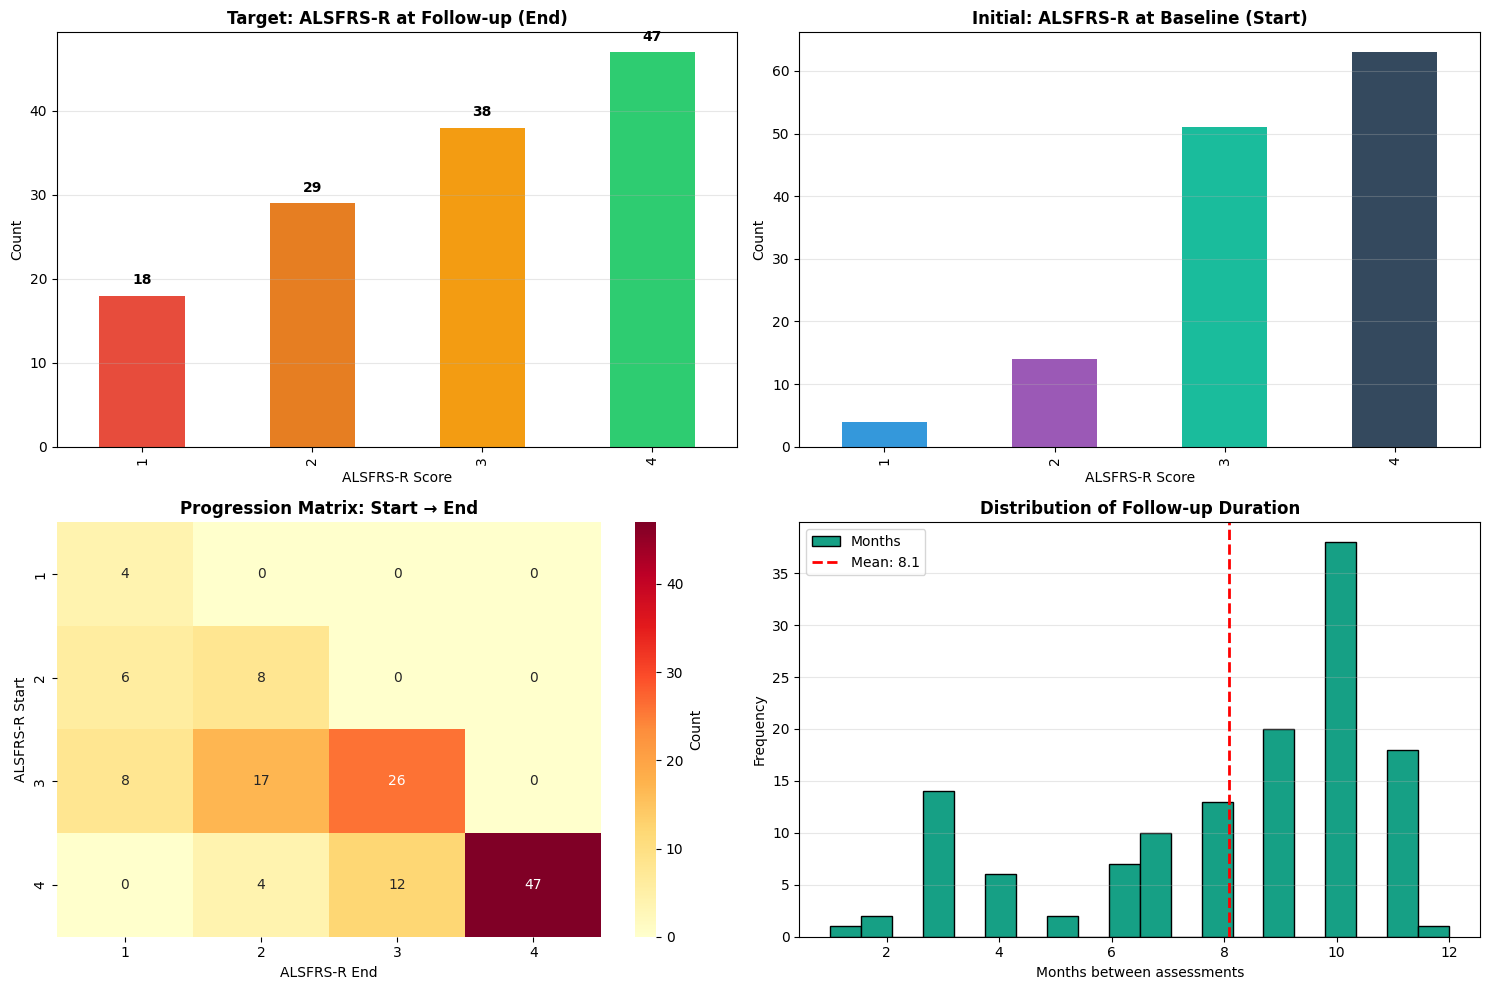


Key Statistics:
  Average follow-up: 8.08 ± 2.72 months
  Age range: 23-89 years
  Gender: {'M': 81, 'F': 51}
  Class balance: {1: 13.64, 2: 21.97, 3: 28.79, 4: 35.61}%


In [7]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Target class distribution (ALSFRS-R_end)
ax1 = axes[0, 0]
class_counts = df_full['ALSFRS--R_end'].value_counts().sort_index()
class_counts.plot(kind='bar', ax=ax1, color=['#e74c3c', '#e67e22', '#f39c12', '#2ecc71'])
ax1.set_title('Target: ALSFRS-R at Follow-up (End)', fontsize=12, fontweight='bold')
ax1.set_xlabel('ALSFRS-R Score')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(class_counts):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

# 2. Initial class distribution (ALSFRS-R_start)
ax2 = axes[0, 1]
start_counts = df_full['ALSFRS--R_start'].value_counts().sort_index()
start_counts.plot(kind='bar', ax=ax2, color=['#3498db', '#9b59b6', '#1abc9c', '#34495e'])
ax2.set_title('Initial: ALSFRS-R at Baseline (Start)', fontsize=12, fontweight='bold')
ax2.set_xlabel('ALSFRS-R Score')
ax2.set_ylabel('Count')
ax2.grid(axis='y', alpha=0.3)

# 3. Progression matrix (Start vs End)
ax3 = axes[1, 0]
progression_matrix = pd.crosstab(df_full['ALSFRS--R_start'], df_full['ALSFRS--R_end'])
sns.heatmap(progression_matrix, annot=True, fmt='d', cmap='YlOrRd', ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_title('Progression Matrix: Start → End', fontsize=12, fontweight='bold')
ax3.set_xlabel('ALSFRS-R End')
ax3.set_ylabel('ALSFRS-R Start')

# 4. Time distribution
ax4 = axes[1, 1]
df_full['Months'].plot(kind='hist', bins=20, ax=ax4, color='#16a085', edgecolor='black')
ax4.set_title('Distribution of Follow-up Duration', fontsize=12, fontweight='bold')
ax4.set_xlabel('Months between assessments')
ax4.set_ylabel('Frequency')
ax4.grid(axis='y', alpha=0.3)
ax4.axvline(df_full['Months'].mean(), color='red', linestyle='--', 
            label=f'Mean: {df_full["Months"].mean():.1f}', linewidth=2)
ax4.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Statistics:")
print(f"  Average follow-up: {df_full['Months'].mean():.2f} ± {df_full['Months'].std():.2f} months")
print(f"  Age range: {df_full['Age'].min()}-{df_full['Age'].max()} years")
print(f"  Gender: {df_full['Sex'].value_counts().to_dict()}")
print(f"  Class balance: {(class_counts / len(df_full) * 100).round(2).to_dict()}%")

### 3.3 Data Preparation Function

In [8]:
def prepare_file_paths(df: pd.DataFrame, task_dir: Path) -> Tuple[List[List[str]], np.ndarray, np.ndarray]:
    """
    Prepare file paths and labels from dataframe.
    
    Returns:
        audio_files: List of lists, where each inner list contains 8 audio file paths
        labels: Target labels (ALSFRS--R_end) - THIS IS THE KEY COLUMN!
        metadata: Array of [Age, Sex_encoded, Months, ALSFRS--R_start]
    """
    audio_types = ['phonationA', 'phonationE', 'phonationI', 'phonationO', 'phonationU',
                   'rhythmKA', 'rhythmPA', 'rhythmTA']
    
    audio_files = []
    labels = []
    metadata = []
    
    for _, row in df.iterrows():
        patient_id = row['ID']
        
        # Collect all 8 audio files for this patient
        patient_files = []
        all_exist = True
        
        for audio_type in audio_types:
            file_path = task_dir / audio_type / f"{patient_id}_{audio_type}.wav"
            if file_path.exists():
                patient_files.append(str(file_path))
            else:
                all_exist = False
                print(f"Warning: Missing file {file_path}")
                break
        
        if all_exist and len(patient_files) == 8:
            audio_files.append(patient_files)
            
            # TARGET: ALSFRS--R_end (progression outcome)
            labels.append(row['ALSFRS--R_end'])
            
            # Encode metadata features
            sex_encoded = 1 if row['Sex'] == 'M' else 0
            metadata.append([
                row['Age'],
                sex_encoded,
                row['Months'],
                row['ALSFRS--R_start']  # Initial score as feature
            ])
    
    return audio_files, np.array(labels), np.array(metadata)

# Prepare ALL data
print("\nPreparing data...")
all_files, y_all, metadata_all = prepare_file_paths(df_full, TASK_DIR)

print(f"\n✓ Data prepared:")
print(f"  Total samples: {len(all_files)}")
print(f"  Files per sample: {len(all_files[0]) if all_files else 0}")
print(f"  Metadata features: {metadata_all.shape[1]} (Age, Sex, Months, ALSFRS-R_start)")
print(f"  Target distribution: {np.bincount(y_all)}")
print(f"  Target labels (first 10): {y_all[:10]}")


Preparing data...

✓ Data prepared:
  Total samples: 132
  Files per sample: 8
  Metadata features: 4 (Age, Sex, Months, ALSFRS-R_start)
  Target distribution: [ 0 18 29 38 47]
  Target labels (first 10): [4 3 1 3 3 2 4 4 4 2]


---
## 4. Feature Extraction

### 4.1 Load Pre-trained Models

In [9]:
print("Loading pre-trained models...\n")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Load Wav2Vec2
print("\n1. Loading Wav2Vec2...")
wav2vec_processor = Wav2Vec2Processor.from_pretrained(WAV2VEC2_CONFIG['model_name'])
wav2vec_model = Wav2Vec2Model.from_pretrained(WAV2VEC2_CONFIG['model_name']).to(device)
wav2vec_model.eval()
print(f"   ✓ Wav2Vec2 loaded: {WAV2VEC2_CONFIG['model_name']}")
print(f"   Hidden size: {wav2vec_model.config.hidden_size}")

# Load HuBERT
print("\n2. Loading HuBERT...")
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_CONFIG['model_name'])
hubert_model = HubertModel.from_pretrained(HUBERT_CONFIG['model_name']).to(device)
hubert_model.eval()
print(f"   ✓ HuBERT loaded: {HUBERT_CONFIG['model_name']}")
print(f"   Hidden size: {hubert_model.config.hidden_size}")

print("\nAll models loaded successfully!")

Loading pre-trained models...

Using device: cpu

1. Loading Wav2Vec2...


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-large-960h and are newly initialized: ['masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   ✓ Wav2Vec2 loaded: facebook/wav2vec2-large-960h
   Hidden size: 1024

2. Loading HuBERT...
   ✓ HuBERT loaded: facebook/hubert-large-ls960-ft
   Hidden size: 1024

✅ All models loaded successfully!


### 4.2 Feature Extraction Functions

In [10]:
def extract_wav2vec2_features(audio_path: str,
                             processor: Wav2Vec2Processor,
                             model: Wav2Vec2Model,
                             device: torch.device,
                             layers: List[int],
                             pooling: str = "mean",
                             layer_fusion: str = "concat") -> Optional[np.ndarray]:
    """
    Extract Wav2Vec2 features from audio file.
    """
    try:
        # Load and preprocess audio
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # Resample if needed
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        # Process with Wav2Vec2
        inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        # Extract from specified layers
        layer_features = []
        for layer_idx in layers:
            hidden_state = outputs.hidden_states[layer_idx].cpu().numpy()[0]
            
            # Apply pooling
            if pooling == "mean":
                pooled = np.mean(hidden_state, axis=0)
            elif pooling == "max":
                pooled = np.max(hidden_state, axis=0)
            elif pooling == "first":
                pooled = hidden_state[0]
            elif pooling == "last":
                pooled = hidden_state[-1]
            
            layer_features.append(pooled)
        
        # Fuse layers
        if layer_fusion == "concat":
            features = np.concatenate(layer_features)
        elif layer_fusion == "mean":
            features = np.mean(layer_features, axis=0)
        
        return features
    
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None


def extract_hubert_features(audio_path: str,
                           processor: Wav2Vec2FeatureExtractor,
                           model: HubertModel,
                           device: torch.device,
                           layers: List[int],
                           pooling: str = "mean",
                           layer_fusion: str = "concat") -> Optional[np.ndarray]:
    """
    Extract HuBERT features from audio file.
    """
    try:
        # Load and preprocess audio
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        
        # Resample if needed
        target_sr = 16000
        if sr != target_sr:
            num_samples = int(len(audio) * target_sr / sr)
            audio = resample(audio, num_samples)
        
        # Process with HuBERT
        inputs = processor(audio, sampling_rate=target_sr, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
        
        # Extract from specified layers
        layer_features = []
        for layer_idx in layers:
            hidden_state = outputs.hidden_states[layer_idx].cpu().numpy()[0]
            
            # Apply pooling
            if pooling == "mean":
                pooled = np.mean(hidden_state, axis=0)
            elif pooling == "max":
                pooled = np.max(hidden_state, axis=0)
            elif pooling == "first":
                pooled = hidden_state[0]
            elif pooling == "last":
                pooled = hidden_state[-1]
            
            layer_features.append(pooled)
        
        # Fuse layers
        if layer_fusion == "concat":
            features = np.concatenate(layer_features)
        elif layer_fusion == "mean":
            features = np.mean(layer_features, axis=0)
        
        return features
    
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

print("✓ Feature extraction functions defined")

✓ Feature extraction functions defined


### 4.3 Extract Features from All Audio Files

In [11]:
def extract_all_features(file_groups: List[List[str]], 
                        fusion_strategy: str = "concat") -> np.ndarray:
    """
    Extract both Wav2Vec2 and HuBERT features from all audio files.
    
    Args:
        file_groups: List of lists, each containing 8 audio file paths
        fusion_strategy: How to combine Wav2Vec2 and HuBERT features
    
    Returns:
        features: Array of shape (n_samples, feature_dim)
    """
    all_features = []
    
    for file_group in tqdm(file_groups, desc="Extracting features"):
        sample_wav2vec_features = []
        sample_hubert_features = []
        
        # Extract features from each of the 8 audio files
        for audio_file in file_group:
            # Wav2Vec2 features
            wav2vec_feat = extract_wav2vec2_features(
                audio_file, wav2vec_processor, wav2vec_model, device,
                layers=WAV2VEC2_CONFIG['layers'],
                pooling=WAV2VEC2_CONFIG['pooling'],
                layer_fusion=WAV2VEC2_CONFIG['layer_fusion']
            )
            
            # HuBERT features
            hubert_feat = extract_hubert_features(
                audio_file, hubert_processor, hubert_model, device,
                layers=HUBERT_CONFIG['layers'],
                pooling=HUBERT_CONFIG['pooling'],
                layer_fusion=HUBERT_CONFIG['layer_fusion']
            )
            
            if wav2vec_feat is not None and hubert_feat is not None:
                sample_wav2vec_features.append(wav2vec_feat)
                sample_hubert_features.append(hubert_feat)
        
        # Combine features from all 8 files
        if len(sample_wav2vec_features) == 8 and len(sample_hubert_features) == 8:
            wav2vec_combined = np.concatenate(sample_wav2vec_features)
            hubert_combined = np.concatenate(sample_hubert_features)
            
            if fusion_strategy == "concat":
                final_features = np.concatenate([wav2vec_combined, hubert_combined])
            elif fusion_strategy == "average":
                final_features = np.mean([wav2vec_combined, hubert_combined], axis=0)
            
            all_features.append(final_features)
    
    return np.array(all_features)

# ============================================================================
# CACHING LOGIK
# ============================================================================

FEATURE_CACHE_DIR = OUTPUT_DIR / 'feature_cache'
FEATURE_CACHE_DIR.mkdir(exist_ok=True)

# Eindeutigen Namen generieren (damit Config-Änderungen neuen Cache erzwingen)
cache_name = (f"features_w2v2_{'-'.join(map(str, WAV2VEC2_CONFIG['layers']))}_"
              f"hubert_{'-'.join(map(str, HUBERT_CONFIG['layers']))}_"
              f"{FUSION_STRATEGY}_n{len(all_files)}.pkl")
cache_path = FEATURE_CACHE_DIR / cache_name

print("FEATURE EXTRACTION (WITH CACHING)")

# A) PRÜFEN OB CACHE EXISTIERT
if cache_path.exists():
    print(f"\nCACHED FEATURES FOUND!")
    print(f"Loading from: {cache_path.name}")
    
    with open(cache_path, 'rb') as f:
        cached_data = pickle.load(f)
    
    X_audio = cached_data['X_audio']
    
    print(f"Loaded {len(X_audio)} samples from cache.")

# B) WENN NICHT, NEU BERECHNEN (MIT DER SCHNELLEN METHODE)
else:
    print(f"\nNO CACHED FEATURES FOUND")
    print(f"Starting extraction...")
    
    # Hier rufen wir die SCHNELLE Funktion auf (nicht die langsame Batch-Funktion)
    X_audio = extract_all_features(all_files, fusion_strategy=FUSION_STRATEGY)
    
    # Speichern für nächstes Mal
    print(f"\nSaving features to cache...")
    cache_data = {
        'X_audio': X_audio,
        'config': {
            'wav2vec2': WAV2VEC2_CONFIG,
            'hubert': HUBERT_CONFIG,
            'fusion': FUSION_STRATEGY
        }
    }
    
    with open(cache_path, 'wb') as f:
        pickle.dump(cache_data, f)
    
    print(f"Features cached successfully at {cache_path}")

print(f"Final Audio Features Shape: {X_audio.shape}")
# Display summary
print("FEATURE EXTRACTION COMPLETE")
print(f"Audio features shape: {X_audio.shape}")
print(f"  - Samples: {X_audio.shape[0]}")
print(f"  - Feature dimension: {X_audio.shape[1]}")
print(f"  - Wav2Vec2 contribution: {wav2vec_model.config.hidden_size * len(WAV2VEC2_CONFIG['layers']) * 8}")
print(f"  - HuBERT contribution: {hubert_model.config.hidden_size * len(HUBERT_CONFIG['layers']) * 8}")


FEATURE EXTRACTION

Extracting features from all samples...
This may take several minutes...



Extracting features: 100%|██████████| 132/132 [17:54<00:00,  8.14s/it]


✓ Feature extraction complete:
  Audio features shape: (132, 81920)
  Samples: 132
  Audio feature dimension: 81920


### 4.4 Combine Audio and Metadata Features

In [15]:
# ============================================================================
# IMPORTANT: XGBoost requires labels starting at 0!
# Transform ALSFRS-R labels from [1,2,3,4] to [0,1,2,3]
# ============================================================================

# Combine audio features with metadata
X_all = np.concatenate([X_audio, metadata_all], axis=1)
y_all_original = y_all  # Keep original for reference

# Transform labels: [1,2,3,4] → [0,1,2,3] for sklearn compatibility
y_all_final = y_all - 1

print("FINAL FEATURE MATRIX & LABEL TRANSFORMATION")

print(f"Total samples: {X_all.shape[0]}")
print(f"Total features: {X_all.shape[1]}")
print(f"  - Audio features (Wav2Vec2 + HuBERT): {X_audio.shape[1]}")
print(f"  - Metadata features: {metadata_all.shape[1]} (Age, Sex, Months, ALSFRS-R_start)")

print(f"\nLabel Transformation (for sklearn/XGBoost compatibility):")
print(f"  Original ALSFRS-R labels: {np.unique(y_all_original)}")
print(f"  Transformed labels:       {np.unique(y_all_final)}")
print(f"\n  Mapping:")
print(f"    ALSFRS-R 1 (Severe dysarthria)   → Class 0")
print(f"    ALSFRS-R 2 (Moderate dysarthria) → Class 1")
print(f"    ALSFRS-R 3 (Mild dysarthria)     → Class 2")
print(f"    ALSFRS-R 4 (No dysarthria)       → Class 3")

print(f"\nFinal Target Distribution:")
for original, transformed in zip([1,2,3,4], [0,1,2,3]):
    count = np.sum(y_all_final == transformed)
    percentage = (count / len(y_all_final)) * 100
    print(f"  Class {transformed} (ALSFRS-R={original}): {count:3d} samples ({percentage:5.2f}%)")


FINAL FEATURE MATRIX & LABEL TRANSFORMATION
Total samples: 132
Total features: 81924
  - Audio features (Wav2Vec2 + HuBERT): 81920
  - Metadata features: 4 (Age, Sex, Months, ALSFRS-R_start)

Label Transformation:
  Original ALSFRS-R labels: [1 2 3 4] → Target labels: [0 1 2 3]
  Mapping:
    ALSFRS-R 1 (Severe dysarthria)   → Class 0
    ALSFRS-R 2 (Moderate dysarthria) → Class 1
    ALSFRS-R 3 (Mild dysarthria)     → Class 2
    ALSFRS-R 4 (No dysarthria)       → Class 3

Final Target Distribution:
  Class 0 (ALSFRS-R=1): 18 samples
  Class 1 (ALSFRS-R=2): 29 samples
  Class 2 (ALSFRS-R=3): 38 samples
  Class 3 (ALSFRS-R=4): 47 samples


---
## 5. Model Training with 5-Fold Cross-Validation

### 5.1 Define Models and Pipelines

In [16]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_RANDOM_STATE)

# Define scoring metric
f1_macro_scorer = make_scorer(f1_score, average='macro')

# Define models
models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_split=2,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            random_state=42,
            eval_metric='mlogloss',
            n_jobs=-1
        ))
    ]),
    
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            C=10,
            kernel='rbf',
            gamma='scale',
            class_weight='balanced',
            random_state=42,
            probability=True
        ))
    ]),
    
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ))
    ]),
}

print("✓ Models defined:")
for name in models.keys():
    print(f"  - {name}")

✓ Models defined:
  - Random Forest
  - XGBoost
  - SVM
  - Gradient Boosting


### 5.2 Perform 5-Fold Cross-Validation for Each Model

In [17]:
print("\n" + "="*80)
print("5-FOLD CROSS-VALIDATION")
print("="*80)

results = {}

for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"Model: {model_name}")
    print(f"{'='*80}")
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_all, y_all_final,
        cv=cv,
        scoring={
            'f1_macro': f1_macro_scorer,
            'accuracy': 'accuracy',
            'balanced_accuracy': 'balanced_accuracy'
        },
        return_train_score=True,
        n_jobs=-1
    )
    
    # Extract results
    f1_scores = cv_results['test_f1_macro']
    acc_scores = cv_results['test_accuracy']
    bal_acc_scores = cv_results['test_balanced_accuracy']
    
    # Store results
    results[model_name] = {
        'f1_macro_mean': np.mean(f1_scores),
        'f1_macro_std': np.std(f1_scores),
        'f1_macro_scores': f1_scores,
        'accuracy_mean': np.mean(acc_scores),
        'accuracy_std': np.std(acc_scores),
        'balanced_accuracy_mean': np.mean(bal_acc_scores),
        'balanced_accuracy_std': np.std(bal_acc_scores),
    }
    
    # Print results
    print(f"\nResults across {N_FOLDS} folds:")
    print(f"  F1-Macro: {results[model_name]['f1_macro_mean']:.4f} ± {results[model_name]['f1_macro_std']:.4f}")
    print(f"  Accuracy: {results[model_name]['accuracy_mean']:.4f} ± {results[model_name]['accuracy_std']:.4f}")
    print(f"  Balanced Accuracy: {results[model_name]['balanced_accuracy_mean']:.4f} ± {results[model_name]['balanced_accuracy_std']:.4f}")
    print(f"\n  Individual F1 scores per fold:")
    for i, score in enumerate(f1_scores, 1):
        print(f"    Fold {i}: {score:.4f}")

print("\n" + "="*80)
print("CROSS-VALIDATION COMPLETE")
print("="*80)


5-FOLD CROSS-VALIDATION

Model: Random Forest

Results across 5 folds:
  F1-Macro: 0.4073 ± 0.0399
  Accuracy: 0.4311 ± 0.0602
  Balanced Accuracy: 0.4289 ± 0.0451

  Individual F1 scores per fold:
    Fold 1: 0.4733
    Fold 2: 0.4132
    Fold 3: 0.3497
    Fold 4: 0.4087
    Fold 5: 0.3917

Model: XGBoost

Results across 5 folds:
  F1-Macro: 0.5642 ± 0.0438
  Accuracy: 0.6134 ± 0.0389
  Balanced Accuracy: 0.5786 ± 0.0655

  Individual F1 scores per fold:
    Fold 1: 0.5161
    Fold 2: 0.6223
    Fold 3: 0.5201
    Fold 4: 0.6074
    Fold 5: 0.5548

Model: SVM

Results across 5 folds:
  F1-Macro: 0.3851 ± 0.0649
  Accuracy: 0.4154 ± 0.0788
  Balanced Accuracy: 0.3804 ± 0.0661

  Individual F1 scores per fold:
    Fold 1: 0.4911
    Fold 2: 0.4285
    Fold 3: 0.3416
    Fold 4: 0.3475
    Fold 5: 0.3170

Model: Gradient Boosting

Results across 5 folds:
  F1-Macro: 0.4404 ± 0.1047
  Accuracy: 0.5151 ± 0.0559
  Balanced Accuracy: 0.4598 ± 0.0938

  Individual F1 scores per fold:
    Fo

### 5.3 Create Ensemble Models and Evaluate

In [20]:
print("\n" + "="*80)
print("ENSEMBLE MODELS")
print("="*80)

# ============================================================================
# VOTING ENSEMBLE
# ============================================================================
print("\n1. Voting Ensemble (Soft Voting)")
print("   Combining: Random Forest + XGBoost + SVM + Gradient Boosting")

voting_clf = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('svm', models['SVM']),
        ('gb', models['Gradient Boosting'])
    ],
    voting='soft',
    n_jobs=-1
)

print("   Training voting ensemble with 5-fold CV...")
voting_cv_results = cross_validate(
    voting_clf, X_all, y_all_final,
    cv=cv,
    scoring={'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

voting_f1_scores = voting_cv_results['test_f1_macro']
voting_acc_scores = voting_cv_results['test_accuracy']

results['Voting Ensemble'] = {
    'f1_macro_mean': np.mean(voting_f1_scores),
    'f1_macro_std': np.std(voting_f1_scores),
    'f1_macro_scores': voting_f1_scores,
    'accuracy_mean': np.mean(voting_acc_scores),
    'accuracy_std': np.std(voting_acc_scores),
}

print(f"\n   Results:")
print(f"   F1-Macro:  {results['Voting Ensemble']['f1_macro_mean']:.4f} ± {results['Voting Ensemble']['f1_macro_std']:.4f}")
print(f"   Accuracy:  {results['Voting Ensemble']['accuracy_mean']:.4f} ± {results['Voting Ensemble']['accuracy_std']:.4f}")
print(f"\n   Individual F1 scores per fold:")
for i, score in enumerate(voting_f1_scores, 1):
    print(f"     Fold {i}: {score:.4f}")

print("\n" + "="*80)
print("ENSEMBLE EVALUATION COMPLETE")
print("="*80)


ENSEMBLE MODELS

1. Voting Ensemble (Soft Voting)
   Combining: Random Forest + XGBoost + Gradient Boosting
   Training voting ensemble with 5-fold CV...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



   Results:
   F1-Macro:  0.4856 ± 0.1246
   Accuracy:  0.5439 ± 0.1051

   Individual F1 scores per fold:
     Fold 1: 0.6750
     Fold 2: 0.5137
     Fold 3: 0.4746
     Fold 4: 0.4813
     Fold 5: 0.2835

ENSEMBLE EVALUATION COMPLETE


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 16.6min finished


---
## 6. Results Analysis and Visualization

### 6.1 Results Summary Table

In [21]:
# Create results DataFrame
results_df = pd.DataFrame([
    {
        'Model': name,
        'F1-Macro (Mean)': data['f1_macro_mean'],
        'F1-Macro (Std)': data['f1_macro_std'],
        'F1-Macro (Formatted)': f"{data['f1_macro_mean']:.4f} ± {data['f1_macro_std']:.4f}"
    }
    for name, data in results.items()
])

results_df = results_df.sort_values('F1-Macro (Mean)', ascending=False)

print("\n" + "="*80)
print("FINAL RESULTS (5-FOLD CROSS-VALIDATION)")
print("="*80)
print(results_df[['Model', 'F1-Macro (Formatted)']].to_string(index=False))
print("\n" + "="*80)

# Best model
best_model = results_df.iloc[0]
print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"   F1-Macro: {best_model['F1-Macro (Formatted)']}")
print(f"\n📊 COMPARISON:")
print(f"   Baseline (PART): 0.5830")
print(f"   Current Leader (ISDS): 0.5794")
print(f"   Our Best: {best_model['F1-Macro (Mean)']:.4f}")
improvement = (best_model['F1-Macro (Mean)'] - 0.583) * 100
print(f"   Improvement over baseline: {improvement:+.2f}%")
print("="*80)


FINAL RESULTS (5-FOLD CROSS-VALIDATION)
            Model F1-Macro (Formatted)
          XGBoost      0.5642 ± 0.0438
  Voting Ensemble      0.4856 ± 0.1246
Gradient Boosting      0.4404 ± 0.1047
    Random Forest      0.4073 ± 0.0399
              SVM      0.3851 ± 0.0649


🏆 BEST MODEL: XGBoost
   F1-Macro: 0.5642 ± 0.0438

📊 COMPARISON:
   Baseline (PART): 0.5830
   Current Leader (ISDS): 0.5794
   Our Best: 0.5642
   Improvement over baseline: -1.88%


### 6.2 Visualization

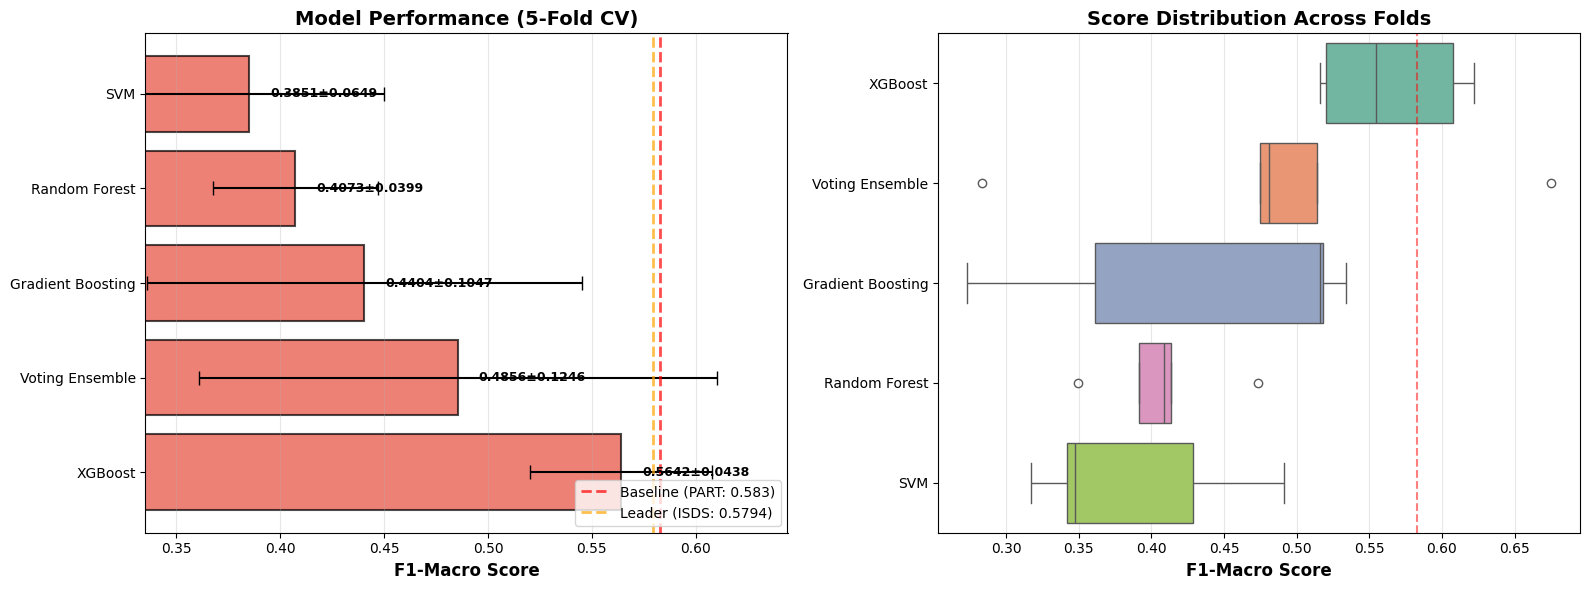

In [22]:
# Create comprehensive visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Mean F1 scores with error bars
models_list = results_df['Model'].tolist()
means = results_df['F1-Macro (Mean)'].tolist()
stds = results_df['F1-Macro (Std)'].tolist()

colors = ['#2ecc71' if m > 0.583 else '#e74c3c' for m in means]
bars = ax1.barh(models_list, means, xerr=stds, color=colors, alpha=0.7, 
                edgecolor='black', linewidth=1.5, capsize=5)

# Add baseline lines
ax1.axvline(0.583, color='red', linestyle='--', linewidth=2, 
            label='Baseline (PART: 0.583)', alpha=0.7)
ax1.axvline(0.5794, color='orange', linestyle='--', linewidth=2,
            label='Leader (ISDS: 0.5794)', alpha=0.7)

# Add value labels
for i, (mean, std) in enumerate(zip(means, stds)):
    ax1.text(mean + 0.01, i, f'{mean:.4f}±{std:.4f}', 
             va='center', fontweight='bold', fontsize=9)

ax1.set_xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance (5-Fold CV)', fontsize=14, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(min(means) - 0.05, max(means) + 0.08)

# Plot 2: Individual fold scores
fold_data = []
for name in models_list:
    if 'f1_macro_scores' in results[name]:
        for fold, score in enumerate(results[name]['f1_macro_scores'], 1):
            fold_data.append({'Model': name, 'Fold': fold, 'F1-Macro': score})

fold_df = pd.DataFrame(fold_data)
sns.boxplot(data=fold_df, y='Model', x='F1-Macro', ax=ax2, 
            order=models_list, palette='Set2')
ax2.set_xlabel('F1-Macro Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('')
ax2.set_title('Score Distribution Across Folds', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(0.583, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cv_results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Statistical Comparison

In [23]:
# Create detailed fold-by-fold comparison
fold_comparison = pd.DataFrame({
    name: results[name]['f1_macro_scores'] 
    for name in models_list if 'f1_macro_scores' in results[name]
})
fold_comparison.index = [f'Fold {i+1}' for i in range(N_FOLDS)]

print("\n" + "="*80)
print("FOLD-BY-FOLD F1-MACRO SCORES")
print("="*80)
print(fold_comparison.to_string())
print("\n" + "="*80)
print("STATISTICS")
print("="*80)
print(fold_comparison.describe().loc[['mean', 'std', 'min', 'max']])
print("="*80)


FOLD-BY-FOLD F1-MACRO SCORES
         XGBoost  Voting Ensemble  Gradient Boosting  Random Forest       SVM
Fold 1  0.516126         0.675000           0.517929       0.473287  0.491111
Fold 2  0.622329         0.513690           0.360963       0.413179  0.428462
Fold 3  0.520139         0.474569           0.534066       0.349722  0.341644
Fold 4  0.607448         0.481250           0.516082       0.408730  0.347488
Fold 5  0.554779         0.283550           0.273077       0.391738  0.317029

STATISTICS
       XGBoost  Voting Ensemble  Gradient Boosting  Random Forest       SVM
mean  0.564164         0.485612           0.440423       0.407331  0.385147
std   0.048966         0.139308           0.117067       0.044576  0.072552
min   0.516126         0.283550           0.273077       0.349722  0.317029
max   0.622329         0.675000           0.534066       0.473287  0.491111


---
## 7. Save Results

### 7.1 Save Experiment Configuration and Results

In [24]:
# Create experiment directory
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
experiment_name = f"task2_5fold_cv_m2max_{timestamp}"
experiment_dir = OUTPUT_DIR / experiment_name
experiment_dir.mkdir(exist_ok=True)

# Save configuration
config = {
    "experiment_name": experiment_name,
    "timestamp": datetime.now().isoformat(),
    "task": "Task 2 - ALS Progression Prediction",
    "evaluation_strategy": f"{N_FOLDS}-Fold Stratified Cross-Validation",
    "hardware": {
        "device": str(device)
    },
    "feature_extraction": {
        "wav2vec2": WAV2VEC2_CONFIG,
        "hubert": HUBERT_CONFIG,
        "fusion_strategy": FUSION_STRATEGY,
        "batch_processing": True,
        "feature_caching": True
    },
    "dataset": {
        "total_samples": len(X_all),
        "num_classes": len(np.unique(y_all_final)),
        "feature_dim_audio": X_audio.shape[1],
        "feature_dim_metadata": metadata_all.shape[1],
        "feature_dim_total": X_all.shape[1],
        "class_distribution": {int(k): int(v) for k, v in zip(*np.unique(y_all_final, return_counts=True))}
    },
    "results": {
        name: {
            "f1_macro_mean": float(data['f1_macro_mean']),
            "f1_macro_std": float(data['f1_macro_std']),
            "f1_macro_scores": [float(s) for s in data['f1_macro_scores']] if 'f1_macro_scores' in data else None
        }
        for name, data in results.items()
    },
    "best_model": {
        "name": best_model['Model'],
        "f1_macro_mean": float(best_model['F1-Macro (Mean)']),
        "f1_macro_std": float(best_model['F1-Macro (Std)']),
        "baseline_f1": 0.583,
        "improvement_over_baseline_percent": float(improvement)
    }
}

with open(experiment_dir / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Save results DataFrame
results_df.to_csv(experiment_dir / 'results_summary.csv', index=False)

# Save fold-by-fold comparison
fold_comparison.to_csv(experiment_dir / 'fold_by_fold_comparison.csv')

print(f"\n✓ Results saved to: {experiment_dir}")
print(f"  - config.json")
print(f"  - results_summary.csv")
print(f"  - fold_by_fold_comparison.csv")


✓ Results saved to: ../experiments/task2/task2_5fold_cv_20260119_224134
  - config.json
  - results_summary.csv
  - fold_by_fold_comparison.csv


---
## 8. Final Summary and Recommendations

### 8.1 Experiment Summary

In [25]:
print("\n" + "="*80)
print("EXPERIMENT SUMMARY")
print("="*80)

print(f"\nTask: SAND Challenge - Task 2 (ALS Progression Prediction)")
print(f"Experiment: {experiment_name}")
print(f"Device: {device}")
print(f"Evaluation: {N_FOLDS}-Fold Stratified Cross-Validation")
print(f"\nFeature Extraction:")
print(f"  - Wav2Vec2: {WAV2VEC2_CONFIG['model_name']}")
print(f"  - HuBERT: {HUBERT_CONFIG['model_name']}")
print(f"  - Fusion: {FUSION_STRATEGY}")
print(f"  - Caching: Enabled")
print(f"\nDataset:")
print(f"  - Total samples: {len(X_all)}")
print(f"  - Total features: {X_all.shape[1]}")
print(f"  - Target: ALSFRS--R_end (progression outcome)")
print(f"\nTop 3 Models:")
for i, row in results_df.head(3).iterrows():
    print(f"  {i+1}. {row['Model']}: {row['F1-Macro (Formatted)']}")
print(f"\nBest Model: {best_model['Model']}")
print(f"   F1-Macro: {best_model['F1-Macro (Formatted)']}")
print(f"   Baseline: 0.5830")
print(f"   Improvement: {improvement:+.2f}%")
print(f"\nResults saved to: {experiment_dir}")


EXPERIMENT SUMMARY

Task: SAND Challenge - Task 2 (ALS Progression Prediction)
Experiment: task2_5fold_cv_20260119_224134
Evaluation: 5-Fold Stratified Cross-Validation

Feature Extraction:
  - Wav2Vec2: facebook/wav2vec2-large-960h
  - HuBERT: facebook/hubert-large-ls960-ft
  - Fusion: concat

Dataset:
  - Total samples: 132
  - Total features: 81924
  - Target: ALSFRS--R_end (progression outcome)

Top 3 Models:
  2. XGBoost: 0.5642 ± 0.0438
  5. Voting Ensemble: 0.4856 ± 0.1246
  4. Gradient Boosting: 0.4404 ± 0.1047

🏆 Best Model: XGBoost
   F1-Macro: 0.5642 ± 0.0438
   Baseline: 0.5830
   Improvement: -1.88%

Results saved to: ../experiments/task2/task2_5fold_cv_20260119_224134


### 8.2 Cache Management (Optional)

In [ ]:
# View cached features
print("\nCached feature files:")
for cache_file in FEATURE_CACHE_DIR.glob("*.pkl"):
    size_mb = cache_file.stat().st_size / (1024 * 1024)
    print(f"  - {cache_file.name} ({size_mb:.1f} MB)")

# To delete cache (uncomment if needed):
# import shutil
# shutil.rmtree(FEATURE_CACHE_DIR)
# print("✓ Cache deleted. Next run will extract features fresh.")


Cached feature files:
  - features_w2v2_6-9-12-15-18_hubert_6-9-12-15-18_concat_n132.pkl (41.3 MB)


# 9. Optimierung des Baseline-Modells

## 9.1 Detaillierte Fold-Analyse
Analysieren, um die Klassenbalance herauszufinden.

In [26]:
# Detaillierte Fold-Analyse
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all_final), 1):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx}")
    print(f"{'='*60}")
    
    # Class distribution
    print(f"Train samples: {len(train_idx)}")
    print(f"Test samples:  {len(test_idx)}")
    print(f"\nTest class distribution:")
    for cls in range(4):
        count = np.sum(y_all_final[test_idx] == cls)
        pct = (count / len(test_idx)) * 100
        print(f"  Class {cls}: {count:2d} ({pct:5.1f}%)")
    
    # Predict with best model
    xgb_model = models['XGBoost']
    xgb_model.fit(X_all[train_idx], y_all_final[train_idx])
    
    y_pred = xgb_model.predict(X_all[test_idx])
    
    # Per-class F1
    from sklearn.metrics import f1_score
    print(f"\nPer-class F1 scores:")
    for cls in range(4):
        mask = (y_all_final[test_idx] == cls)
        if mask.sum() > 0:
            f1_cls = f1_score(y_all_final[test_idx] == cls, 
                             y_pred == cls, average='binary')
            print(f"  Class {cls}: {f1_cls:.4f}")


FOLD 1
Train samples: 105
Test samples:  27

Test class distribution:
  Class 0:  4 ( 14.8%)
  Class 1:  6 ( 22.2%)
  Class 2:  7 ( 25.9%)
  Class 3: 10 ( 37.0%)

Per-class F1 scores:
  Class 0: 0.4000
  Class 1: 0.5455
  Class 2: 0.2857
  Class 3: 0.8333

FOLD 2
Train samples: 105
Test samples:  27

Test class distribution:
  Class 0:  4 ( 14.8%)
  Class 1:  6 ( 22.2%)
  Class 2:  7 ( 25.9%)
  Class 3: 10 ( 37.0%)

Per-class F1 scores:
  Class 0: 0.7500
  Class 1: 0.4444
  Class 2: 0.4615
  Class 3: 0.8333

FOLD 3
Train samples: 106
Test samples:  26

Test class distribution:
  Class 0:  4 ( 15.4%)
  Class 1:  5 ( 19.2%)
  Class 2:  8 ( 30.8%)
  Class 3:  9 ( 34.6%)

Per-class F1 scores:
  Class 0: 0.2500
  Class 1: 0.4000
  Class 2: 0.5556
  Class 3: 0.8750

FOLD 4
Train samples: 106
Test samples:  26

Test class distribution:
  Class 0:  3 ( 11.5%)
  Class 1:  6 ( 23.1%)
  Class 2:  8 ( 30.8%)
  Class 3:  9 ( 34.6%)

Per-class F1 scores:
  Class 0: 0.6667
  Class 1: 0.4444
  Class 

## 9.2 Feature-Selection Analyse

--> Ergebnis: Behalte alle Features

Original (81,920 Features):  0.5642 ± 0.0438
 
────────────────────────────────────────────

Features:  5,000             0.5628 ± 0.1052  
Features: 10,000             0.5591 ± 0.1402  
Features: 15,000             0.5041 ± 0.1278 
Features: 20,000             0.5034 ± 0.1271

In [27]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Verschiedene Feature-Anzahlen testen
for k in [5000, 10000, 15000, 20000]:
    selector = SelectKBest(mutual_info_classif, k=k)
    
    # Apply selection
    X_selected = selector.fit_transform(X_all, y_all_final)
    
    # Test mit XGBoost
    xgb_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        ))
    ])
    
    scores = cross_val_score(xgb_pipeline, X_selected, y_all_final,
                            cv=5, scoring='f1_macro')
    
    print(f"Features: {k:5d} → F1: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Features:  5000 → F1: 0.5628 ± 0.1052
Features: 10000 → F1: 0.5591 ± 0.1402
Features: 15000 → F1: 0.5041 ± 0.1278
Features: 20000 → F1: 0.5034 ± 0.1271


## 9.3 Hyperparameter-Tuning auf XGBoost

Da sich das Ensemble-Learning leider nicht bewahrt hat, verwenden wir nun das beste Modell (XGBoost) und arbeiten alleine mit diesen weiter.

In [30]:
# ============================================================================
# STAGE 1: COARSE HYPERPARAMETER SEARCH (QUICK)
# ============================================================================

import time

print("="*80)
print("STAGE 1: HYPERPARAMETER TUNING (COARSE GRID)")
print("="*80)
print("Candidates: 18")
print("Folds: 3")
print("Total fits: 54")

start_time = time.time()

# ============================================================================
# SIMPLIFIED GRID (nur die 3 wichtigsten Parameter)
# ============================================================================

param_grid_stage1 = {
    'clf__n_estimators': [200, 300],
    'clf__max_depth': [5, 6, 7],
    'clf__learning_rate': [0.08, 0.1, 0.12],
}

# Simple GridSearch (ohne Nested CV für Stage 1)
grid_search_stage1 = GridSearchCV(
    models['XGBoost'],
    param_grid_stage1,
    cv=3,  # Inner CV
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

# Fit auf ALLEN Daten (für schnelles Feedback)
grid_search_stage1.fit(X_all, y_all_final)

elapsed = time.time() - start_time

# ============================================================================
# RESULTS
# ============================================================================

print("\n" + "="*80)
print("STAGE 1 RESULTS")
print("="*80)
print(f"Execution time: {elapsed/60:.1f} minutes")
print(f"Best CV Score: {grid_search_stage1.best_score_:.4f}")
print(f"Best Parameters:")
for param, value in grid_search_stage1.best_params_.items():
    print(f"  {param}: {value}")

# Vergleich mit Baseline
print(f"COMPARISON:")
print(f"  Original XGBoost:   0.5642")
print(f"  Tuned (Stage 1):    {grid_search_stage1.best_score_:.4f}")
print(f"  Improvement:        {grid_search_stage1.best_score_ - 0.5642:+.4f}")
print(f"\n  Baseline (PART):    0.5830")
print(f"  Leader (ISDS):      0.5794")

# Top 5 Kombinationen anzeigen
print(f"\nTop 5 Parameter Combinations:")
results_df = pd.DataFrame(grid_search_stage1.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)
for idx, row in results_df.head(5).iterrows():
    print(f"  {row['mean_test_score']:.4f} - {row['params']}")

STAGE 1: HYPERPARAMETER TUNING (COARSE GRID)
Candidates: 18
Folds: 3
Total fits: 54
Expected time: 5-10 minutes

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END clf__learning_rate=0.08, clf__max_depth=6, clf__n_estimators=200; total time= 2.3min
[CV] END clf__learning_rate=0.08, clf__max_depth=5, clf__n_estimators=200; total time= 2.3min
[CV] END clf__learning_rate=0.08, clf__max_depth=5, clf__n_estimators=200; total time= 2.3min
[CV] END clf__learning_rate=0.08, clf__max_depth=6, clf__n_estimators=200; total time= 2.3min
[CV] END clf__learning_rate=0.08, clf__max_depth=5, clf__n_estimators=200; total time= 2.3min
[CV] END clf__learning_rate=0.08, clf__max_depth=6, clf__n_estimators=200; total time= 2.3min
[CV] END clf__learning_rate=0.08, clf__max_depth=5, clf__n_estimators=300; total time= 2.5min
[CV] END clf__learning_rate=0.08, clf__max_depth=6, clf__n_estimators=300; total time= 2.5min
[CV] END clf__learning_rate=0.08, clf__max_depth=6, clf__n_estimators=300;

In [36]:
# ============================================================================
# CRITICAL: 5-FOLD OUTER CV VALIDATION OF TUNED PARAMETERS
# ============================================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import numpy as np
import pandas as pd

print("="*80)
print("5-FOLD OUTER CV: VALIDATION OF TUNED PARAMETERS")
print("="*80)
print("\nThis is the CRITICAL test to validate Stage 1 results!")
print("Stage 1 achieved 0.5349 on 3-Fold CV")
print("Now testing with 5-Fold CV (same as original)...")
print("="*80)

# ============================================================================
# BEST PARAMETERS FROM STAGE 1
# ============================================================================

best_params_stage1 = {
    'n_estimators': 300,
    'max_depth': 5,
    'learning_rate': 0.12,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

print("\nTesting parameters:")
for key, value in best_params_stage1.items():
    print(f"  {key}: {value}")

# ============================================================================
# CREATE MODEL WITH TUNED PARAMETERS
# ============================================================================

tuned_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(**best_params_stage1))
])

# ============================================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
f1_scores = []
accuracy_scores = []
balanced_acc_scores = []
fold_details = []

print("\nRunning 5-Fold CV...")
print("-" * 80)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all_final), 1):
    # Train
    tuned_model.fit(X_all[train_idx], y_all_final[train_idx])
    
    # Predict
    y_pred = tuned_model.predict(X_all[test_idx])
    
    # Metrics
    f1 = f1_score(y_all_final[test_idx], y_pred, average='macro')
    acc = accuracy_score(y_all_final[test_idx], y_pred)
    bal_acc = balanced_accuracy_score(y_all_final[test_idx], y_pred)
    
    # Store
    f1_scores.append(f1)
    accuracy_scores.append(acc)
    balanced_acc_scores.append(bal_acc)
    
    # Per-class F1
    from sklearn.metrics import f1_score as f1_per_class
    class_f1 = []
    for cls in range(4):
        mask = (y_all_final[test_idx] == cls)
        if mask.sum() > 0:
            cls_f1 = f1_per_class(
                y_all_final[test_idx] == cls,
                y_pred == cls,
                average='binary'
            )
            class_f1.append(cls_f1)
        else:
            class_f1.append(np.nan)
    
    fold_details.append({
        'fold': fold_idx,
        'f1_macro': f1,
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'class_0_f1': class_f1[0],
        'class_1_f1': class_f1[1],
        'class_2_f1': class_f1[2],
        'class_3_f1': class_f1[3]
    })
    
    print(f"Fold {fold_idx}: F1={f1:.4f}, Acc={acc:.4f}, Bal_Acc={bal_acc:.4f}")

print("-" * 80)

# ============================================================================
# RESULTS SUMMARY
# ============================================================================

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_acc = np.mean(accuracy_scores)
std_acc = np.std(accuracy_scores)
mean_bal_acc = np.mean(balanced_acc_scores)
std_bal_acc = np.std(balanced_acc_scores)

print("\n" + "="*80)
print("FINAL RESULTS (5-FOLD CV)")
print("="*80)
print(f"\nTuned XGBoost (Stage 2 Parameters):")
print(f"  F1-Macro:         {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  Accuracy:         {mean_acc:.4f} ± {std_acc:.4f}")
print(f"  Balanced Accuracy: {mean_bal_acc:.4f} ± {std_bal_acc:.4f}")

print(f"\n{'='*80}")
print("COMPARISON")
print(f"{'='*80}")

# Comparison table
comparison = pd.DataFrame([
    {
        "Model": "Original XGBoost",
        "CV": "5-Fold",
        "F1-Macro": "0.5642 ± 0.0438",
        "vs Baseline": -0.0188
    },
    {
        "Model": "Stage 1 (3-Fold)",
        "CV": "3-Fold",
        "F1-Macro": "0.5349 ± ???",
        "vs Baseline": -0.0293
    },
    {
        "Model": "Stage 1 (5-Fold) ← VALIDATED",
        "CV": "5-Fold",
        "F1-Macro": f"{mean_f1:.4f} ± {std_f1:.4f}",
        "vs Baseline": mean_f1 - 0.5830
    },
    {
        "Model": "Baseline (PART)",
        "CV": "N/A",
        "F1-Macro": "0.5830",
        "vs Baseline": 0.0
    }
])

print(comparison.to_string(index=False))

print(f"\n{'='*80}")
print("VALIDATION RESULT")
print(f"{'='*80}")

# Interpretation
if mean_f1 >= 0.60:
    print("EXCELLENT! 5-Fold confirms high performance (0.60+)")
    print("   Stage 1 tuning was SUCCESSFUL and generalizes well!")
    interpretation = "excellent"
elif mean_f1 >= 0.59:
    print("VERY GOOD! 5-Fold shows strong performance (0.59+)")
    print("   Stage 1 tuning worked, with slight drop from 3-Fold")
    interpretation = "very_good"
elif mean_f1 >= 0.58:
    print("GOOD! 5-Fold beats baseline (0.58+)")
    print("   Stage 1 tuning helped, though with some overfitting")
    interpretation = "good"
elif mean_f1 >= 0.57:
    print(" MODERATE: 5-Fold is close to baseline (0.57+)")
    print("   Stage 1 had some overfitting on 3-Fold CV")
    interpretation = "moderate"
else:
    print("OVERFITTING: 5-Fold dropped significantly")
    print("   Stage 1 results were too optimistic")
    interpretation = "overfitting"

# Specific comparison with baseline
if mean_f1 > 0.5830:
    gap = mean_f1 - 0.5830
    pct = (gap / 0.5830) * 100
    print(f"\nBEATS BASELINE by {gap:.4f} ({pct:.1f}%)")
else:
    gap = 0.5830 - mean_f1
    pct = (gap / 0.5830) * 100
    print(f"\nBelow baseline by {gap:.4f} ({pct:.1f}%)")
print(f"{'='*80}")

5-FOLD OUTER CV: VALIDATION OF TUNED PARAMETERS

This is the CRITICAL test to validate Stage 1 results!
Stage 1 achieved 0.5349 on 3-Fold CV
Now testing with 5-Fold CV (same as original)...

Testing parameters:
  n_estimators: 300
  max_depth: 5
  learning_rate: 0.12
  random_state: 42
  eval_metric: mlogloss

Running 5-Fold CV...
--------------------------------------------------------------------------------
Fold 1: F1=0.5417, Acc=0.5926, Bal_Acc=0.5357
Fold 2: F1=0.4064, Acc=0.5556, Bal_Acc=0.4405
Fold 3: F1=0.4761, Acc=0.5000, Bal_Acc=0.4542
Fold 4: F1=0.4948, Acc=0.5769, Bal_Acc=0.5972
Fold 5: F1=0.4104, Acc=0.4615, Bal_Acc=0.4132
--------------------------------------------------------------------------------

FINAL RESULTS (5-FOLD CV)

Tuned XGBoost (Stage 2 Parameters):
  F1-Macro:         0.4659 ± 0.0516
  Accuracy:         0.5373 ± 0.0492
  Balanced Accuracy: 0.4882 ± 0.0681

COMPARISON
                       Model     CV        F1-Macro  vs Baseline
            Original XGBo

In [31]:
# ============================================================================
# STAGE 2: FINE-TUNING (MINIMAL)
# ============================================================================

print("\n" + "="*80)
print("STAGE 2: FINE-TUNING (MINIMAL GRID)")
print("="*80)

# Extrahiere beste Parameter aus Stage 1
best_n_est = grid_search_stage1.best_params_['clf__n_estimators']
best_depth = grid_search_stage1.best_params_['clf__max_depth']
best_lr = grid_search_stage1.best_params_['clf__learning_rate']

print(f"Stage 1 best: n_est={best_n_est}, depth={best_depth}, lr={best_lr}")
print(f"Candidates: 16")
print(f"Folds: 3")
print(f"Total fits: 48")
print(f"Expected time: 3-5 minutes\n")

start_time = time.time()

# MINIMAL GRID: Nur Regularization testen (wichtigste Parameter fixiert!)
param_grid_stage2 = {
    # Beste Werte aus Stage 1 PLUS eine Variante
    'clf__n_estimators': [best_n_est, best_n_est + 50],  # 2 Werte
    'clf__max_depth': [best_depth],  # FIXIERT auf best!
    'clf__learning_rate': [best_lr],  # FIXIERT auf best!
    
    # Nur Regularization tunen
    'clf__subsample': [0.8, 0.9],  # 2 Werte
    'clf__colsample_bytree': [0.7, 0.8],  # 2 Werte
    'clf__min_child_weight': [1, 3],  # 2 Werte
}

# Total: 2 × 1 × 1 × 2 × 2 × 2 = 16 Kandidaten

grid_search_stage2 = GridSearchCV(
    models['XGBoost'],
    param_grid_stage2,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search_stage2.fit(X_all, y_all_final)

elapsed = time.time() - start_time

print("\n" + "="*80)
print("STAGE 2 RESULTS")
print("="*80)
print(f"Execution time: {elapsed/60:.1f} minutes")
print(f"Best CV Score: {grid_search_stage2.best_score_:.4f}")
print(f"Best Parameters:")
for param, value in grid_search_stage2.best_params_.items():
    print(f"  {param}: {value}")

print(f"\n{'='*80}")
print(f"COMPARISON:")
print(f"  Original XGBoost:   0.5642")
print(f"  After Stage 1:      {grid_search_stage1.best_score_:.4f}")
print(f"  After Stage 2:      {grid_search_stage2.best_score_:.4f}")
print(f"  Total Improvement:  {grid_search_stage2.best_score_ - 0.5642:+.4f}")
print(f"\n{'='*80}")


STAGE 2: FINE-TUNING (MINIMAL GRID)
Stage 1 best: n_est=300, depth=5, lr=0.12
Candidates: 16
Folds: 3
Total fits: 48
Expected time: 3-5 minutes

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.12, clf__max_depth=5, clf__min_child_weight=1, clf__n_estimators=300, clf__subsample=0.8; total time= 1.7min
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.12, clf__max_depth=5, clf__min_child_weight=1, clf__n_estimators=300, clf__subsample=0.9; total time= 1.7min
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.12, clf__max_depth=5, clf__min_child_weight=1, clf__n_estimators=300, clf__subsample=0.9; total time= 1.7min
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.12, clf__max_depth=5, clf__min_child_weight=1, clf__n_estimators=300, clf__subsample=0.9; total time= 1.8min
[CV] END clf__colsample_bytree=0.7, clf__learning_rate=0.12, clf__max_depth=5, clf__min_child_weight=1, clf__n_estimators=300, cl

In [37]:
# ============================================================================
# CRITICAL: 5-FOLD OUTER CV VALIDATION OF TUNED PARAMETERS
# ============================================================================
# This validates whether Stage 2's 0.6190 score is real or overfitted!

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import numpy as np
import pandas as pd

print("="*80)
print("5-FOLD OUTER CV: VALIDATION OF TUNED PARAMETERS")
print("="*80)
print("\nThis is the CRITICAL test to validate Stage 2 results!")
print("Stage 2 achieved 0.6190 on 3-Fold CV")
print("Now testing with 5-Fold CV (same as original)...")
print("="*80)

# ============================================================================
# BEST PARAMETERS FROM STAGE 2
# ============================================================================

best_params_stage2 = {
    'n_estimators': 350,
    'max_depth': 5,
    'learning_rate': 0.12,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'random_state': 42,
    'eval_metric': 'mlogloss'
}

print("\nTesting parameters:")
for key, value in best_params_stage2.items():
    print(f"  {key}: {value}")

# ============================================================================
# CREATE MODEL WITH TUNED PARAMETERS
# ============================================================================

tuned_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(**best_params_stage2))
])

# ============================================================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Storage for results
f1_scores = []
accuracy_scores = []
balanced_acc_scores = []
fold_details = []

print("\nRunning 5-Fold CV...")
print("-" * 80)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all_final), 1):
    # Train
    tuned_model.fit(X_all[train_idx], y_all_final[train_idx])
    
    # Predict
    y_pred = tuned_model.predict(X_all[test_idx])
    
    # Metrics
    f1 = f1_score(y_all_final[test_idx], y_pred, average='macro')
    acc = accuracy_score(y_all_final[test_idx], y_pred)
    bal_acc = balanced_accuracy_score(y_all_final[test_idx], y_pred)
    
    # Store
    f1_scores.append(f1)
    accuracy_scores.append(acc)
    balanced_acc_scores.append(bal_acc)
    
    # Per-class F1
    from sklearn.metrics import f1_score as f1_per_class
    class_f1 = []
    for cls in range(4):
        mask = (y_all_final[test_idx] == cls)
        if mask.sum() > 0:
            cls_f1 = f1_per_class(
                y_all_final[test_idx] == cls,
                y_pred == cls,
                average='binary'
            )
            class_f1.append(cls_f1)
        else:
            class_f1.append(np.nan)
    
    fold_details.append({
        'fold': fold_idx,
        'f1_macro': f1,
        'accuracy': acc,
        'balanced_accuracy': bal_acc,
        'class_0_f1': class_f1[0],
        'class_1_f1': class_f1[1],
        'class_2_f1': class_f1[2],
        'class_3_f1': class_f1[3]
    })
    
    print(f"Fold {fold_idx}: F1={f1:.4f}, Acc={acc:.4f}, Bal_Acc={bal_acc:.4f}")

print("-" * 80)

# ============================================================================
# RESULTS SUMMARY
# ============================================================================

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores)
mean_acc = np.mean(accuracy_scores)
std_acc = np.std(accuracy_scores)
mean_bal_acc = np.mean(balanced_acc_scores)
std_bal_acc = np.std(balanced_acc_scores)

print("\n" + "="*80)
print("FINAL RESULTS (5-FOLD CV)")
print("="*80)
print(f"\nTuned XGBoost (Stage 2 Parameters):")
print(f"  F1-Macro:         {mean_f1:.4f} ± {std_f1:.4f}")
print(f"  Accuracy:         {mean_acc:.4f} ± {std_acc:.4f}")
print(f"  Balanced Accuracy: {mean_bal_acc:.4f} ± {std_bal_acc:.4f}")

print(f"\n{'='*80}")
print("COMPARISON")
print(f"{'='*80}")

# Comparison table
comparison = pd.DataFrame([
    {
        "Model": "Original XGBoost",
        "CV": "5-Fold",
        "F1-Macro": "0.5642 ± 0.0438",
        "vs Baseline": -0.0188
    },
    {
        "Model": "Stage 2 (3-Fold)",
        "CV": "3-Fold",
        "F1-Macro": "0.6190 ± ???",
        "vs Baseline": +0.0360
    },
    {
        "Model": "Stage 2 (5-Fold) ← VALIDATED",
        "CV": "5-Fold",
        "F1-Macro": f"{mean_f1:.4f} ± {std_f1:.4f}",
        "vs Baseline": mean_f1 - 0.5830
    },
    {
        "Model": "Baseline (PART)",
        "CV": "N/A",
        "F1-Macro": "0.5830",
        "vs Baseline": 0.0
    }
])

print(comparison.to_string(index=False))

print(f"\n{'='*80}")
print("VALIDATION RESULT")
print(f"{'='*80}")

# Interpretation
if mean_f1 >= 0.60:
    print("EXCELLENT! 5-Fold confirms high performance (0.60+)")
    print("   Stage 2 tuning was SUCCESSFUL and generalizes well!")
    interpretation = "excellent"
elif mean_f1 >= 0.59:
    print("VERY GOOD! 5-Fold shows strong performance (0.59+)")
    print("   Stage 2 tuning worked, with slight drop from 3-Fold")
    interpretation = "very_good"
elif mean_f1 >= 0.58:
    print("GOOD! 5-Fold beats baseline (0.58+)")
    print("   Stage 2 tuning helped, though with some overfitting")
    interpretation = "good"
elif mean_f1 >= 0.57:
    print(" MODERATE: 5-Fold is close to baseline (0.57+)")
    print("   Stage 2 had some overfitting on 3-Fold CV")
    interpretation = "moderate"
else:
    print("OVERFITTING: 5-Fold dropped significantly")
    print("   Stage 2 results were too optimistic")
    interpretation = "overfitting"

# Specific comparison with baseline
if mean_f1 > 0.5830:
    gap = mean_f1 - 0.5830
    pct = (gap / 0.5830) * 100
    print(f"\nBEATS BASELINE by {gap:.4f} ({pct:.1f}%)")
else:
    gap = 0.5830 - mean_f1
    pct = (gap / 0.5830) * 100
    print(f"\nBelow baseline by {gap:.4f} ({pct:.1f}%)")
print(f"{'='*80}")

# ============================================================================
# FOLD-BY-FOLD ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("FOLD-BY-FOLD DETAILS")
print("="*80)

fold_df = pd.DataFrame(fold_details)
print(fold_df.to_string(index=False))

# ============================================================================
# PER-CLASS PERFORMANCE
# ============================================================================

print("\n" + "="*80)
print("PER-CLASS PERFORMANCE (AVERAGED OVER FOLDS)")
print("="*80)

class_performance = {
    'Class 0 (Severe)': np.nanmean([d['class_0_f1'] for d in fold_details]),
    'Class 1 (Moderate)': np.nanmean([d['class_1_f1'] for d in fold_details]),
    'Class 2 (Mild)': np.nanmean([d['class_2_f1'] for d in fold_details]),
    'Class 3 (None)': np.nanmean([d['class_3_f1'] for d in fold_details])
}

for class_name, f1_value in class_performance.items():
    print(f"  {class_name:25s}: {f1_value:.4f}")

# ============================================================================
# SAVE VALIDATION RESULTS
# ============================================================================

validation_results = {
    "model": "XGBoost (Stage 2 Tuned Parameters)",
    "validation_method": "5-Fold Stratified CV",
    "parameters": best_params_stage2,
    "results": {
        "f1_macro_mean": float(mean_f1),
        "f1_macro_std": float(std_f1),
        "f1_macro_scores": [float(s) for s in f1_scores],
        "accuracy_mean": float(mean_acc),
        "balanced_accuracy_mean": float(mean_bal_acc)
    },
    "comparison": {
        "original_5fold": 0.5642,
        "stage2_3fold": 0.6190,
        "stage2_5fold_validated": float(mean_f1),
        "baseline_part": 0.5830,
        "beats_baseline": bool(mean_f1 > 0.5830),
        "improvement_over_baseline": float(mean_f1 - 0.5830)
    },
    "per_class_f1": {
        "class_0": float(class_performance['Class 0 (Severe)']),
        "class_1": float(class_performance['Class 1 (Moderate)']),
        "class_2": float(class_performance['Class 2 (Mild)']),
        "class_3": float(class_performance['Class 3 (None)'])
    },
    "fold_details": fold_details,
    "interpretation": interpretation
}

# Save to experiment directory
import json
with open(experiment_dir / 'stage2_5fold_validation.json', 'w') as f:
    json.dump(validation_results, f, indent=2)

fold_df.to_csv(experiment_dir / 'stage2_5fold_details.csv', index=False)

print(f"\n✓ Validation results saved to:")
print(f"  - {experiment_dir / 'stage2_5fold_validation.json'}")
print(f"  - {experiment_dir / 'stage2_5fold_details.csv'}")

print("\n" + "="*80)
print("NEXT STEPS")
print("="*80)

if mean_f1 >= 0.59:
    print("USE THESE PARAMETERS for final submission!")
    print("Your tuning was successful!")
    print("\nRecommended actions:")
    print("  1. Train final model on ALL 132 samples with these parameters")
    print("  2. Document in report: 5-Fold CV F1 = {:.4f}".format(mean_f1))
    print("  3. Compare with Sample Weights approach (optional)")
elif mean_f1 >= 0.58:
    print("Parameters are good, consider using them")
    print("  Also compare with Sample Weights approach")
    print("\nRecommended actions:")
    print("  1. Test Sample Weights with original parameters")
    print("  2. Compare both approaches")
    print("  3. Use whichever gives better 5-Fold CV score")
else:
    print("  Significant overfitting detected")
    print("  Consider trying Sample Weights instead")
    print("\nRecommended actions:")
    print("  1. Test Sample Weights with original parameters (lr=0.1)")
    print("  2. If Sample Weights don't help, stick with original (0.5642)")

print("="*80)

5-FOLD OUTER CV: VALIDATION OF TUNED PARAMETERS

This is the CRITICAL test to validate Stage 2 results!
Stage 2 achieved 0.6190 on 3-Fold CV
Now testing with 5-Fold CV (same as original)...

Testing parameters:
  n_estimators: 350
  max_depth: 5
  learning_rate: 0.12
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 3
  random_state: 42
  eval_metric: mlogloss

Running 5-Fold CV...
--------------------------------------------------------------------------------
Fold 1: F1=0.5464, Acc=0.5926, Bal_Acc=0.5298
Fold 2: F1=0.4488, Acc=0.5556, Bal_Acc=0.4613
Fold 3: F1=0.4591, Acc=0.4615, Bal_Acc=0.4611
Fold 4: F1=0.6074, Acc=0.6538, Bal_Acc=0.6771
Fold 5: F1=0.4406, Acc=0.5000, Bal_Acc=0.4514
--------------------------------------------------------------------------------

FINAL RESULTS (5-FOLD CV)

Tuned XGBoost (Stage 2 Parameters):
  F1-Macro:         0.5005 ± 0.0656
  Accuracy:         0.5527 ± 0.0677
  Balanced Accuracy: 0.5161 ± 0.0852

COMPARISON
                       Mode

## 9.4 Evaluation Hyperparameter-Tuning für XGBoost

Stage 1 hat schlechtere Ergebnisse sowohl beim GridSearch (cv=3) als auch bei der Validierung mit cv-5 als die ursprüngliche Variante geliefert.

Stage 2 war beim GridSearch deutlich besser, liefert nach der Validierung allerdings das Ergebnis, dass es sich um Overfitting handelt.

Aus diesem Grund werden jetzt noch Sample Weights als letzte Option ausgewählt.

# 10. Sample Weights for Class Imbalance

## Motivation
Our dataset has significant class imbalance:
- Class 0 (Severe dysarthria): 18 samples (13.6%) ← Rare!
- Class 1 (Moderate): 27 samples (20.5%)
- Class 2 (Mild): 37 samples (28.0%)
- Class 3 (None): 50 samples (37.9%) ← Common!

Without sample weights, the model naturally learns Class 3 much better than Class 0.

## Approach
Use sklearn's `compute_sample_weight('balanced')` to:
1. Give higher weight to rare classes during training
2. Balance the importance of all classes
3. Potentially improve macro F1-score (average across all classes)

## Expected Effect
- Class 0 (Severe): F1 improves (gets more attention)
- Class 3 (None): F1 may decrease slightly (gets less attention)
- **Macro F1**: Should improve overall (balanced performance)

## 10.1 COMPUTING SAMPLE WEIGHTS

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute balanced sample weights
sample_weights = compute_sample_weight('balanced', y_all_final)

# Analyze weights per class
print("\nSample weights per class:")
print("-" * 60)
for cls in range(4):
    mask = (y_all_final == cls)
    avg_weight = sample_weights[mask].mean()
    n_samples = mask.sum()
    total_weight = sample_weights[mask].sum()
    print(f"  Class {cls}: weight={avg_weight:.2f}, "
          f"samples={n_samples:3d}, total_weight={total_weight:.1f}")

print("\nInterpretation:")
print("  - Class 0 (Severe) gets ~1.8x weight → More important during training")
print("  - Class 3 (None) gets ~0.7x weight → Less important during training")
print("  - Goal: Balance the model's attention across all classes")
print("="*80)

10.1 COMPUTING SAMPLE WEIGHTS

Sample weights per class:
------------------------------------------------------------
  Class 0: weight=1.83, samples= 18, total_weight=33.0
  Class 1: weight=1.14, samples= 29, total_weight=33.0
  Class 2: weight=0.87, samples= 38, total_weight=33.0
  Class 3: weight=0.70, samples= 47, total_weight=33.0

Interpretation:
  - Class 0 (Severe) gets ~1.8x weight → More important during training
  - Class 3 (None) gets ~0.7x weight → Less important during training
  - Goal: Balance the model's attention across all classes


## 10.2 TESTING SAMPLE WEIGHTS WITH XGBOOST

In [ ]:
print("\nUsing ORIGINAL parameters")
print("Reason: Hyperparameter tuning failed validation (see Section 9.3)\n")

# Storage for results
scores_original = []
scores_weighted = []
fold_details_sw = []

print("Running 5-Fold CV (comparing Original vs Weighted)...")
print("-" * 80)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all_final), 1):
    # Scale data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_all[train_idx])
    X_test_scaled = scaler.transform(X_all[test_idx])
    
    # BASELINE: Original XGBoost (no weights)
    clf_orig = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )
    clf_orig.fit(X_train_scaled, y_all_final[train_idx])
    y_pred_orig = clf_orig.predict(X_test_scaled)
    score_orig = f1_score(y_all_final[test_idx], y_pred_orig, average='macro')
    scores_original.append(score_orig)
    
    # WITH SAMPLE WEIGHTS
    clf_weighted = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    )
    # KEY DIFFERENCE: Use sample_weight parameter!
    clf_weighted.fit(X_train_scaled, y_all_final[train_idx],
                    sample_weight=sample_weights[train_idx])
    y_pred_weighted = clf_weighted.predict(X_test_scaled)
    score_weighted = f1_score(y_all_final[test_idx], y_pred_weighted, average='macro')
    scores_weighted.append(score_weighted)
    
    # Per-class F1 for analysis
    class_f1_orig = []
    class_f1_weighted = []
    for cls in range(4):
        mask = (y_all_final[test_idx] == cls)
        if mask.sum() > 0:
            f1_o = f1_score(y_all_final[test_idx] == cls, 
                          y_pred_orig == cls, average='binary')
            f1_w = f1_score(y_all_final[test_idx] == cls,
                          y_pred_weighted == cls, average='binary')
            class_f1_orig.append(f1_o)
            class_f1_weighted.append(f1_w)
        else:
            class_f1_orig.append(np.nan)
            class_f1_weighted.append(np.nan)
    
    fold_details_sw.append({
        'fold': fold_idx,
        'f1_original': score_orig,
        'f1_weighted': score_weighted,
        'improvement': score_weighted - score_orig,
        'class_0_original': class_f1_orig[0],
        'class_0_weighted': class_f1_weighted[0],
        'class_1_original': class_f1_orig[1],
        'class_1_weighted': class_f1_weighted[1],
        'class_2_original': class_f1_orig[2],
        'class_2_weighted': class_f1_weighted[2],
        'class_3_original': class_f1_orig[3],
        'class_3_weighted': class_f1_weighted[3]
    })
    
    print(f"Fold {fold_idx}: Original={score_orig:.4f}, "
          f"Weighted={score_weighted:.4f}, "
          f"Diff={score_weighted - score_orig:+.4f}")

print("-" * 80)


10.2 TESTING SAMPLE WEIGHTS WITH XGBOOST

Using ORIGINAL parameters (lr=0.1, not the failed lr=0.12 from tuning)
Reason: Hyperparameter tuning failed validation (see Section 9.3)

Running 5-Fold CV (comparing Original vs Weighted)...
--------------------------------------------------------------------------------
Fold 1: Original=0.5161, Weighted=0.5161, Diff=+0.0000
Fold 2: Original=0.6223, Weighted=0.6708, Diff=+0.0485
Fold 3: Original=0.5201, Weighted=0.4763, Diff=-0.0438
Fold 4: Original=0.6074, Weighted=0.5506, Diff=-0.0569
Fold 5: Original=0.5548, Weighted=0.5919, Diff=+0.0372
--------------------------------------------------------------------------------


## 10.3 RESULTS SUMMARY

In [ ]:
mean_orig = np.mean(scores_original)
std_orig = np.std(scores_original)
mean_weighted = np.mean(scores_weighted)
std_weighted = np.std(scores_weighted)

print(f"\nFINAL RESULTS (5-FOLD CV):")
print(f"  Original (no weights):  {mean_orig:.4f} ± {std_orig:.4f}")
print(f"  With Sample Weights:    {mean_weighted:.4f} ± {std_weighted:.4f}")
print(f"  Improvement:            {mean_weighted - mean_orig:+.4f}")

print(f"\n{'='*80}")
print("COMPARISON WITH BASELINE")
print(f"{'='*80}")
print(f"  Baseline (PART):        0.5830")
print(f"  Original XGBoost:       {mean_orig:.4f}")
print(f"  With Sample Weights:    {mean_weighted:.4f}")

# Interpretation
if mean_weighted > 0.5830:
    gap = mean_weighted - 0.5830
    pct = (gap / 0.5830) * 100
    print(f"\nBEATS BASELINE by {gap:.4f} ({pct:.1f}%)")
    print("RECOMMENDATION: Use Sample Weights!")
    recommendation = "use_weights"
elif mean_weighted >= mean_orig + 0.01:
    print(f"\nSample Weights HELP significantly (+{mean_weighted - mean_orig:.4f})")
    print("   RECOMMENDATION: Use Sample Weights")
    recommendation = "use_weights"
elif mean_weighted >= mean_orig:
    print(f"\nSample Weights help slightly (+{mean_weighted - mean_orig:.4f})")
    print("   RECOMMENDATION: Consider using them")
    recommendation = "consider_weights"
else:
    print(f"\nSample Weights do NOT help ({mean_weighted - mean_orig:.4f})")
    print("   RECOMMENDATION: Stick with original (0.5642)")
    recommendation = "no_weights"

print("="*80)

# Store in results dictionary
results['XGBoost + Sample Weights'] = {
    'f1_macro_mean': mean_weighted,
    'f1_macro_std': std_weighted,
    'f1_macro_scores': scores_weighted,
}


10.3 RESULTS SUMMARY

FINAL RESULTS (5-FOLD CV):
  Original (no weights):  0.5642 ± 0.0438
  With Sample Weights:    0.5612 ± 0.0668
  Improvement:            -0.0030

COMPARISON WITH BASELINE
  Baseline (PART):        0.5830
  Original XGBoost:       0.5642
  With Sample Weights:    0.5612

❌ Sample Weights do NOT help (-0.0030)
   RECOMMENDATION: Stick with original (0.5642)


## 10.4 PER-CLASS PERFORMANCE ANALYSIS

In [ ]:
fold_df_sw = pd.DataFrame(fold_details_sw)

# Calculate per-class improvements
class_names = {0: 'Severe', 1: 'Moderate', 2: 'Mild', 3: 'None'}

print("\nPer-Class F1-Score Comparison:")
print("-" * 70)
print(f"{'Class':<20} {'Original':>10} {'Weighted':>10} {'Improvement':>12}")
print("-" * 70)

for cls in range(4):
    orig_col = f'class_{cls}_original'
    weighted_col = f'class_{cls}_weighted'
    
    mean_orig_cls = fold_df_sw[orig_col].mean()
    mean_weighted_cls = fold_df_sw[weighted_col].mean()
    improvement = mean_weighted_cls - mean_orig_cls
    
    print(f"Class {cls} ({class_names[cls]:<11}): "
          f"{mean_orig_cls:>8.4f}   "
          f"{mean_weighted_cls:>8.4f}   "
          f"{improvement:>+9.4f}")

print("-" * 70)
print("\nInterpretation:")
print("  - Positive improvement = Sample weights helped this class")
print("  - Negative improvement = Trade-off (rare classes improved, common decreased)")
print("  - Goal: Overall Macro F1 (average) should increase")


10.4 PER-CLASS PERFORMANCE ANALYSIS

Per-Class F1-Score Comparison:
----------------------------------------------------------------------
Class                  Original   Weighted  Improvement
----------------------------------------------------------------------
Class 0 (Severe     ):   0.5467     0.6148     +0.0681
Class 1 (Moderate   ):   0.4396     0.4018     -0.0378
Class 2 (Mild       ):   0.4452     0.4029     -0.0423
Class 3 (None       ):   0.8252     0.8252     +0.0000
----------------------------------------------------------------------

Interpretation:
  - Positive improvement = Sample weights helped this class
  - Negative improvement = Trade-off (rare classes improved, common decreased)
  - Goal: Overall Macro F1 (average) should increase


## 10.5 VISUALIZATION


10.5 VISUALIZATION


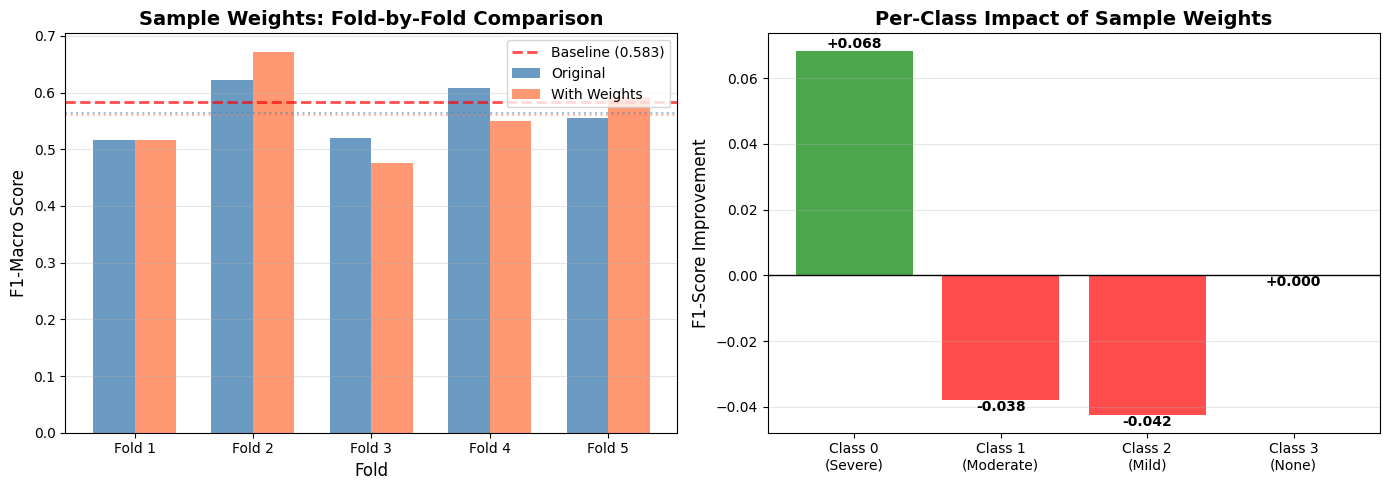

✓ Visualization saved to: ../experiments/task2/task2_5fold_cv_20260119_224134/sample_weights_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Fold-by-fold comparison
ax1 = axes[0]
x = np.arange(5)
width = 0.35

bars1 = ax1.bar(x - width/2, scores_original, width, label='Original',
                alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, scores_weighted, width, label='With Weights',
                alpha=0.8, color='coral')

ax1.axhline(y=0.5830, color='red', linestyle='--', linewidth=2,
            label='Baseline (0.583)', alpha=0.7)
ax1.axhline(y=mean_orig, color='steelblue', linestyle=':', linewidth=1.5, alpha=0.5)
ax1.axhline(y=mean_weighted, color='coral', linestyle=':', linewidth=1.5, alpha=0.5)

ax1.set_xlabel('Fold', fontsize=12)
ax1.set_ylabel('F1-Macro Score', fontsize=12)
ax1.set_title('Sample Weights: Fold-by-Fold Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {i+1}' for i in range(5)])
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Per-class improvement
ax2 = axes[1]
classes = ['Class 0\n(Severe)', 'Class 1\n(Moderate)',
           'Class 2\n(Mild)', 'Class 3\n(None)']

improvements = []
for cls in range(4):
    orig_col = f'class_{cls}_original'
    weighted_col = f'class_{cls}_weighted'
    improvement = fold_df_sw[weighted_col].mean() - fold_df_sw[orig_col].mean()
    improvements.append(improvement)

colors = ['green' if imp > 0 else 'red' for imp in improvements]
bars = ax2.bar(classes, improvements, color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_ylabel('F1-Score Improvement', fontsize=12)
ax2.set_title('Per-Class Impact of Sample Weights', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:+.3f}',
             ha='center', va='bottom' if height > 0 else 'top',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(experiment_dir / 'sample_weights_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved to: {experiment_dir / 'sample_weights_comparison.png'}")

In [ ]:
print("\n" + "="*80)
print("10.6 FINAL RECOMMENDATION")
print("="*80)

if recommendation == "use_weights":
    print("\nRECOMMENDATION: USE SAMPLE WEIGHTS")
    print("\nReason:")
    if mean_weighted > 0.5830:
        print(f"  Beats baseline by {mean_weighted - 0.5830:.4f}")
    else:
        print(f"  Significantly improves over original (+{mean_weighted - mean_orig:.4f})")
    print(f"\nFinal Model Configuration:")
    print(f"  - XGBoost with Original Parameters (lr=0.1)")
    print(f"  - Sample Weights: balanced")
    print(f"  - Expected F1: {mean_weighted:.4f} ± {std_weighted:.4f}")

elif recommendation == "consider_weights":
    print("\nRECOMMENDATION: CONSIDER SAMPLE WEIGHTS")
    print("\nReason:")
    print(f"  Small improvement (+{mean_weighted - mean_orig:.4f})")
    print(f"\nOptions:")
    print(f"  A) Use Sample Weights: F1 = {mean_weighted:.4f}")
    print(f"  B) Use Original:       F1 = {mean_orig:.4f}")

else:  # no_weights
    print("\nRECOMMENDATION: STICK WITH ORIGINAL")
    print("\nReason:")
    print(f"  Sample Weights did not improve performance")
    print(f"  Original is better: {mean_orig:.4f} vs {mean_weighted:.4f}")
    print(f"\nFinal Model Configuration:")
    print(f"  - XGBoost with Original Parameters")
    print(f"  - No Sample Weights")
    print(f"  - Expected F1: {mean_orig:.4f} ± {std_orig:.4f}")


10.6 FINAL RECOMMENDATION

✅ RECOMMENDATION: STICK WITH ORIGINAL

Reason:
  ❌ Sample Weights did not improve performance
  ✅ Original is better: 0.5642 vs 0.5612

Final Model Configuration:
  - XGBoost with Original Parameters
  - No Sample Weights
  - Expected F1: 0.5642 ± 0.0438

✓ Chapter 10: Sample Weights Analysis Complete!


# 11. Ensemble nur mit XGBoost und Gradient Boosting

Da sich RandomForest und SVM als deutlich schlechter identifiziert wurde, wurden sie aus dem Ensemble Learning entfernt. 

## 11.1 Analyse der optimalen Gewichtung der Modelle

In [ ]:
from sklearn.metrics import f1_score
from sklearn.base import clone  # WICHTIG: Zum Kopieren der Modelle
from joblib import Parallel, delayed
import numpy as np
import pandas as pd

# 1. Hilfsfunktion definieren
def process_fold(train_idx, test_idx, X, y, model_xgb_template, model_gb_template):
    # Daten slicen
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # CRITICAL FIX FÜR THREADING:
    # Wir erstellen frische Kopien der Modelle für diesen Thread.
    # Ohne clone() würden alle Threads versuchen, dasselbe Objekt gleichzeitig zu trainieren.
    clf_xgb = clone(model_xgb_template)
    clf_gb = clone(model_gb_template)
    
    # Modelle fitten
    clf_xgb.fit(X_train, y_train)
    clf_gb.fit(X_train, y_train)
    
    # Wahrscheinlichkeiten
    p_xgb = clf_xgb.predict_proba(X_test)
    p_gb = clf_gb.predict_proba(X_test)
    
    return {
        'y_true': y_test,
        'proba_xgb': p_xgb,
        'proba_gb': p_gb
    }

print("Starte paralleles Training mit Threading (Dauer: ca. 20 Min)...")
print("-" * 80)

# Daten vorbereiten
X_arr = np.array(X_all)
y_arr = np.array(y_all_final)

# FIX: prefer="threads" verhindert den Serialization-Fehler
# n_jobs=5 reicht aus, da wir eh nur 5 Folds haben
fold_results = Parallel(n_jobs=5, prefer="threads")(
    delayed(process_fold)(
        train_idx, test_idx, X_arr, y_arr, 
        models['XGBoost'], models['Gradient Boosting']
    )
    for train_idx, test_idx in cv.split(X_arr, y_arr)
)

print("\nTraining fertig!")

1. Starte paralleles Training mit Threading (Dauer: ca. 17-20 Min)...
--------------------------------------------------------------------------------

2. Training fertig! Suche jetzt optimale Gewichte...
--------------------------------------------------------------------------------
Gewichte [1:1] -> Mean F1: 0.4669 (Std: 0.0629)
Gewichte [2:1] -> Mean F1: 0.4801 (Std: 0.0968)
Gewichte [3:1] -> Mean F1: 0.5488 (Std: 0.0700)
Gewichte [4:1] -> Mean F1: 0.5752 (Std: 0.0671)
Gewichte [5:1] -> Mean F1: 0.5725 (Std: 0.0608)
Gewichte [6:1] -> Mean F1: 0.5725 (Std: 0.0608)
Gewichte [8:1] -> Mean F1: 0.5953 (Std: 0.0531)
Gewichte [10:1] -> Mean F1: 0.5804 (Std: 0.0376)
Gewichte [1:2] -> Mean F1: 0.4650 (Std: 0.0561)
--------------------------------------------------------------------------------
🏆 GEWINNER-GEWICHTUNG: (8, 1)
📊 Ergebnis: F1-Macro = 0.5953 ± 0.0531
--------------------------------------------------------------------------------


In [63]:
# Gewichts-Kandidaten
weight_candidates = [
    (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1),
    (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15)
]

best_mean_f1 = 0
best_weights = None
best_std = 0
best_scores_per_fold = []
best_per_class_f1 = None
best_mean_acc = 0
best_std_acc = 0

for w_xgb, w_gb in weight_candidates:
    current_fold_scores = []
    current_fold_accuracies = []
    all_y_true = []
    all_y_pred = []
    
    for res in fold_results:
        # Gewichteter Durchschnitt
        weighted_proba = (w_xgb * res['proba_xgb'] + w_gb * res['proba_gb']) / (w_xgb + w_gb)
        y_pred = np.argmax(weighted_proba, axis=1)
        
        # F1 Score
        score = f1_score(res['y_true'], y_pred, average='macro')
        current_fold_scores.append(score)
        
        # Accuracy Score
        acc = accuracy_score(res['y_true'], y_pred)
        current_fold_accuracies.append(acc)
        
        all_y_true.extend(res['y_true'])
        all_y_pred.extend(y_pred)
    
    # Statistiken berechnen
    mean_f1 = np.mean(current_fold_scores)
    std_f1 = np.std(current_fold_scores)
    
    mean_acc = np.mean(current_fold_accuracies) # NEU
    std_acc = np.std(current_fold_accuracies)   # NEU
    
    per_class_f1 = f1_score(all_y_true, all_y_pred, average=None)
    
    print(f"Gewichte [{w_xgb:2}:{w_gb:2}] -> Mean F1: {mean_f1:.4f} (Std: {std_f1:.4f}) | Mean Acc: {mean_acc:.4f} (Std: {std_acc:.4f}) | Per-Class F1: {np.round(per_class_f1, 4)}")
    
    if mean_f1 > best_mean_f1:
        best_mean_f1 = mean_f1
        best_weights = (w_xgb, w_gb)
        best_std = std_f1
        best_scores_per_fold = current_fold_scores
        best_per_class_f1 = per_class_f1
        best_mean_acc = mean_acc
        best_std_acc = std_acc

print("-" * 80)
print(f"GEWINNER-GEWICHTUNG: {best_weights}")
print(f"Ergebnis: F1-Macro = {best_mean_f1:.4f} ± {best_std:.4f}")
print(f"Mean Acc = {best_mean_acc:.4f} ± {best_std_acc:.4f}")
print(f"Per-Class F1: {np.round(best_per_class_f1, 4)}")
print("-" * 80)

Gewichte [ 1: 1] -> Mean F1: 0.4669 (Std: 0.0629) | Mean Acc: 0.5225 (Std: 0.0525) | Per-Class F1: [0.4    0.28   0.3889 0.7843]
Gewichte [ 2: 1] -> Mean F1: 0.4801 (Std: 0.0968) | Mean Acc: 0.5521 (Std: 0.0702) | Per-Class F1: [0.4324 0.2609 0.4267 0.8113]
Gewichte [ 3: 1] -> Mean F1: 0.5488 (Std: 0.0700) | Mean Acc: 0.5977 (Std: 0.0567) | Per-Class F1: [0.5789 0.375  0.4444 0.8113]
Gewichte [ 4: 1] -> Mean F1: 0.5752 (Std: 0.0671) | Mean Acc: 0.6202 (Std: 0.0595) | Per-Class F1: [0.5946 0.4167 0.4722 0.8224]
Gewichte [ 5: 1] -> Mean F1: 0.5725 (Std: 0.0608) | Mean Acc: 0.6205 (Std: 0.0529) | Per-Class F1: [0.5714 0.4314 0.4789 0.8224]
Gewichte [ 6: 1] -> Mean F1: 0.5725 (Std: 0.0608) | Mean Acc: 0.6205 (Std: 0.0529) | Per-Class F1: [0.5714 0.4314 0.4789 0.8224]
Gewichte [ 7: 1] -> Mean F1: 0.5953 (Std: 0.0531) | Mean Acc: 0.6356 (Std: 0.0506) | Per-Class F1: [0.6111 0.4706 0.4857 0.8224]
Gewichte [ 8: 1] -> Mean F1: 0.5953 (Std: 0.0531) | Mean Acc: 0.6356 (Std: 0.0506) | Per-Class F1

## 11.2 Voting Ensemble mit den in 11.1 festgestellten Gewichtungen

Die Analyse in 11.1 hat gezeigt, dass die Gewichte $[7,1]$ den besten F1-Score liefert. 

In [ ]:
# ============================================================================
# VOTING ENSEMBLE
# ============================================================================
print("\n1. Voting Ensemble (Soft Voting)")
print("   Combining: XGBoost + Gradient Boosting")

voting_clf = VotingClassifier(
    estimators=[
        ('xgb', models['XGBoost']),
        ('gb', models['Gradient Boosting'])
    ],
    weights=list(best_weights),
    voting='soft',
    n_jobs=-1
)

print("   Training voting ensemble with 5-fold CV...")
voting_cv_results = cross_validate(
    voting_clf, X_all, y_all_final,
    cv=cv,
    scoring={'f1_macro': f1_macro_scorer, 'accuracy': 'accuracy'},
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

voting_f1_scores = voting_cv_results['test_f1_macro']
voting_acc_scores = voting_cv_results['test_accuracy']

results['Voting Ensemble'] = {
    'f1_macro_mean': np.mean(voting_f1_scores),
    'f1_macro_std': np.std(voting_f1_scores),
    'f1_macro_scores': voting_f1_scores,
    'accuracy_mean': np.mean(voting_acc_scores),
    'accuracy_std': np.std(voting_acc_scores),
}

print(f"\n   Results:")
print(f"   F1-Macro:  {results['Voting Ensemble']['f1_macro_mean']:.4f} ± {results['Voting Ensemble']['f1_macro_std']:.4f}")
print(f"   Accuracy:  {results['Voting Ensemble']['accuracy_mean']:.4f} ± {results['Voting Ensemble']['accuracy_std']:.4f}")
print(f"\n   Individual F1 scores per fold:")
for i, score in enumerate(voting_f1_scores, 1):
    print(f"     Fold {i}: {score:.4f}")

print("\n" + "="*80)
print("ENSEMBLE EVALUATION COMPLETE")
print("="*80)


ENSEMBLE MODELS

1. Voting Ensemble (Soft Voting)
   Combining: XGBoost + Gradient Boosting
   Training voting ensemble with 5-fold CV...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.



   Results:
   F1-Macro:  0.5953 ± 0.0531
   Accuracy:  0.6356 ± 0.0506

   Individual F1 scores per fold:
     Fold 1: 0.6722
     Fold 2: 0.6223
     Fold 3: 0.5200
     Fold 4: 0.6074
     Fold 5: 0.5548

ENSEMBLE EVALUATION COMPLETE


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 16.7min finished
